# 06 — DOMINANT vs GAD-NR: Grafo de Grupos (G)

Este notebook entrena y compara dos detectores de anomalías sobre el grafo de grupos `G`
usando la librería **PyGOD 1.1.0**, replicando la metodología del notebook 05 (grafo M)
adaptada al grafo de grupos.

- **DOMINANT** (Ding et al., SDM 2019): línea base consolidada en la literatura — encoder GCN
  compartido con dos decoders que reconstruyen estructura y atributos por separado.
- **GAD-NR** (Roy et al., WSDM 2024): estado del arte en la familia GNN+AE — reconstruye el
  vecindario completo de cada nodo (features propias, grado y distribución de atributos de vecinos).

## Diferencias clave respecto al grafo M

| Aspecto | Grafo M | Grafo G |
|---|---|---|
| Nodos | 11.371 miembros | 456 grupos |
| Aristas únicas | 1.176.024 | 6.692 |
| Features/nodo | 3 (geográficas) | 35 (size, activity, category one-hot) |
| Densidad | 0.018 (disperso) | 0.065 (×4 más denso) |
| Grado medio | 207 | 29 |

El grafo G es **mucho más pequeño y con muchas más features que el grafo M**. Esta diferencia es
relevante porque el comportamiento del curriculum de GAD-NR observado en el grafo M (sección 4.1
del notebook 05) está condicionado por la asimetría entre la escala del loss de grado (rango
0-2356) y la de features (3 dimensiones con poca varianza). En G la asimetría es menor y se
espera un comportamiento del curriculum distinto.

## Esquema del notebook

| Sección | Contenido |
|---------|-----------|
| 0 | Imports y configuración |
| 1 | Carga del grafo G |
| 2 | Fundamento teórico: DOMINANT y GAD-NR |
| 3 | Entrenamiento de DOMINANT |
| 4 | Entrenamiento de GAD-NR |
| 5 | Consenso final y tipología de anomalías |
| 6 | Spotlight — candidatos del EDA |
| 7 | Comparativa DOMINANT vs GAD-NR |
| 8 | Visualización t-SNE de los embeddings |
| 9 | Guardado de resultados |


## 0. Imports y configuración

In [1]:
%matplotlib inline

import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from pygod.detector import DOMINANT, GADNR
from scipy.stats import rankdata, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, '..')
from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT,
    FS, FONT,
)
apply_theme()

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_idx = 0 if torch.cuda.is_available() else -1
print(f'Device : {device}')
print(f'PyGOD  : DOMINANT y GADNR importados correctamente')

c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyGOD  : DOMINANT y GADNR importados correctamente


## 1. Carga del grafo G

Cargamos el objeto `Data` del grafo G generado en el notebook `04_feature_engineering.ipynb`.
Tanto DOMINANT como GAD-NR usan el grafo completo durante el entrenamiento — no hacen split
de aristas porque son modelos de detección de anomalías no supervisados, no de predicción de
enlaces. Necesitan ver toda la estructura para aprender el patrón normal.

PyGOD requiere un objeto `Data` con solo `x` y `edge_index` — los atributos adicionales
como `group_ids` o `edge_weight` deben eliminarse para evitar errores de conversión.


In [2]:
data_G = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_G.pt'), weights_only=False)
print(data_G)
print(f'\nNodos          : {data_G.num_nodes}')
print(f'Aristas únicas : {data_G.num_edges // 2}')
print(f'Features/nodo  : {data_G.num_node_features}')

# Guardamos los IDs originales antes de limpiar el objeto Data
group_ids = data_G.group_ids  # lista de group_id en el mismo orden que los nodos

# Objeto limpio para PyGOD — solo x y edge_index
data_G_clean = Data(
    x=data_G.x,
    edge_index=data_G.edge_index,
)
print(f'\ndata_G_clean: {data_G_clean}')


Data(x=[456, 35], edge_index=[2, 13384], edge_weight=[13384], group_ids=[456])

Nodos          : 456
Aristas únicas : 6692
Features/nodo  : 35

data_G_clean: Data(x=[456, 35], edge_index=[2, 13384])


In [3]:
# Metadatos de grupos para interpretar resultados
meta_groups = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-groups.csv'))

# DataFrame base indexado por group_id — se enriquecerá con los scores
id_to_idx = {gid: i for i, gid in enumerate(group_ids)}
base_df = pd.DataFrame({'group_id': group_ids})
base_df['idx'] = base_df.index
base_df = base_df.merge(
    meta_groups[['group_id', 'group_name', 'category_name', 'num_members', 'organizer_id']],
    on='group_id', how='left'
)
# Renombramos group_name a 'name' para mantener la convención del notebook 05
base_df = base_df.rename(columns={'group_name': 'name'})

# Grado de cada nodo (aristas únicas / 2 porque el grafo es no dirigido y duplicado)
edge_src = data_G.edge_index[0].numpy()
degree = np.bincount(edge_src, minlength=data_G.num_nodes) // 2  # cada arista aparece dos veces
base_df['degree'] = degree

print(f'base_df: {base_df.shape}')
base_df.head()


base_df: (456, 7)


,group_id,idx,name,category_name,num_members,organizer_id,degree
0,339011,0,Nashville Hiking Meetup,Outdoors & Adventure,15838,4353803,68
1,19728145,1,Stepping Out Social Dance Meetup,Dancing,1778,118484462,91
2,6335372,2,Nashville soccer,Sports & Recreation,2869,108448302,29
3,10016242,3,NashJS,Tech,1975,8111102,53
4,21174496,4,20's & 30's Women looking for girlfriends,Socializing,2782,184580248,38


## 2. Fundamento teórico: DOMINANT y GAD-NR

El fundamento teórico de ambos modelos es idéntico al descrito en el notebook 05 (grafo M).
Se repite aquí brevemente para que este notebook sea autocontenido.

### 2.1 DOMINANT (Ding et al., SDM 2019)

DOMINANT extiende el GAE estándar con un segundo decoder. Tiene tres componentes:

**Encoder GCN compartido.** Produce embeddings latentes $Z$ combinando features $X$ y estructura $A$:
$$Z = \text{GCN}(X, A)$$

**Decoder de estructura.** Producto interno con sigmoide — idéntico al GAE clásico:
$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$

**Decoder de atributos.** Una GCN que reconstruye la matriz de features original desde los embeddings:
$$\hat{X} = \text{GCN}(Z, A)$$

La función de pérdida combina los dos errores de reconstrucción ponderados por `weight` $\in [0, 1]$:
$$\mathcal{L} = (1 - w) \cdot \|A - \hat{A}\|_F^2 + w \cdot \|X - \hat{X}\|_F^2$$

El anomaly score de cada nodo se calcula de forma análoga:
$$s_i = (1 - w) \cdot s_i^{struct} + w \cdot s_i^{attr}$$

En este notebook tratamos $s_i^{struct}$ y $s_i^{attr}$ como **señales independientes**
para mantener la distinción entre anomalía estructural y de atributo.

### 2.2 GAD-NR (Roy et al., WSDM 2024)

GAD-NR reconstruye el **vecindario completo** de cada nodo, capturando tres dimensiones:

**Reconstrucción de features propias.** Error entre las features reales del nodo y su reconstrucción:
$$\mathcal{L}_{feat} = \|x_i - \hat{x}_i\|^2$$

**Reconstrucción de grado.** Error entre el grado real y el grado predicho por un decoder MLP:
$$\mathcal{L}_{deg} = \text{CrossEntropy}(d_i, \hat{d}_i)$$

**Reconstrucción de la distribución de vecinos.** Divergencia KL entre la distribución real
de features de los vecinos y la distribución reconstruida (modelada como Gaussiana):
$$\mathcal{L}_{neigh} = D_{KL}(p_{neigh}(x) \| q_{neigh}(z))$$

### 2.3 Hiperparámetros para el grafo G

Los hiperparámetros se han ajustado al menor tamaño del grafo G (456 nodos vs 11.371 de M)
y a su mayor dimensionalidad de features (35 vs 3). Los cambios principales son:

| Hiperparámetro | Grafo M | Grafo G | Motivo |
|---|---|---|---|
| `hid_dim` | 64 | 32 | Grafo más pequeño, menos riesgo de underfit con dim menor |
| `epoch` | 300 | 300 | Sin cambio — convergencia full-batch rápida |
| `dropout` (GADNR) | 0.1 | 0.2 | Más regularización con menos datos |
| `weight` (DOM) | 0.2 | 0.5 | Más peso a atributos: en G tenemos 35 features ricas |


## 3. Entrenamiento de DOMINANT

Configuración análoga al notebook 05 con los ajustes documentados en la sección 2.3:
`hid_dim` reducido a 32 (grafo pequeño) y `weight=0.5` (balance equilibrado entre estructura
y atributos, ya que ahora tenemos 35 features ricas).


In [4]:
dominant = DOMINANT(
    hid_dim=64,
    num_layers=4,       # 2 capas encoder + 2 capas decoder
    dropout=0.0,
    weight_decay=0.0,
    act=F.relu,
    sigmoid_s=False,
    weight=0.5,         # peso del error de atributo: equilibrado porque G tiene 35 features ricas
    contamination=0.05, # P95 — 5% de anomalías
    lr=0.004,
    epoch=300,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando DOMINANT sobre el grafo G...')
dominant.fit(data_G_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {dominant.decision_score_.shape}')
print(f'  min={dominant.decision_score_.min():.4f}, '
      f'max={dominant.decision_score_.max():.4f}, '
      f'mean={dominant.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {dominant.label_.sum().item()} '
      f'({dominant.label_.float().mean().item():.1%})')


Entrenando DOMINANT sobre el grafo G...
Epoch 0000: Loss 9.9556 |  | Time 0.63
Epoch 0001: Loss 4.0513 |  | Time 0.01
Epoch 0002: Loss 3.0072 |  | Time 0.01
Epoch 0003: Loss 3.0089 |  | Time 0.01
Epoch 0004: Loss 3.1394 |  | Time 0.01
Epoch 0005: Loss 3.2636 |  | Time 0.01
Epoch 0006: Loss 3.1997 |  | Time 0.01
Epoch 0007: Loss 3.0926 |  | Time 0.01
Epoch 0008: Loss 3.0324 |  | Time 0.01
Epoch 0009: Loss 3.0081 |  | Time 0.01
Epoch 0010: Loss 2.9948 |  | Time 0.01
Epoch 0011: Loss 2.9807 |  | Time 0.01
Epoch 0012: Loss 2.9633 |  | Time 0.01
Epoch 0013: Loss 2.9444 |  | Time 0.01
Epoch 0014: Loss 2.9272 |  | Time 0.01
Epoch 0015: Loss 2.9133 |  | Time 0.01
Epoch 0016: Loss 2.8997 |  | Time 0.01
Epoch 0017: Loss 2.8830 |  | Time 0.01
Epoch 0018: Loss 2.8646 |  | Time 0.01
Epoch 0019: Loss 2.8496 |  | Time 0.01
Epoch 0020: Loss 2.8401 |  | Time 0.01
Epoch 0021: Loss 2.8341 |  | Time 0.01
Epoch 0022: Loss 2.8281 |  | Time 0.01
Epoch 0023: Loss 2.8211 |  | Time 0.01
Epoch 0024: Loss 2.8142 

In [5]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo de DOMINANT.
    
    double_recon_loss calcula:
      attr_error   = sqrt(sum((x - x_)^2, dim=1))
      struct_error = sqrt(sum((s - s_)^2, dim=1))
      score = weight * attr_error + (1 - weight) * struct_error
    """
    model = detector.model
    model.eval()

    data_proc = data.clone()
    model.process_graph(data_proc)  # añade data_proc.s (adyacencia densa)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)

    x_hat, s_hat = model(x, edge_index)

    # RMSE por nodo — igual que double_recon_loss
    attr_scores   = torch.sqrt(torch.sum((x - x_hat) ** 2, dim=1)).cpu().numpy()
    struct_scores = torch.sqrt(torch.sum((s_real - s_hat) ** 2, dim=1)).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_G_clean)

print(f'DOM struct — min={dom_struct.min():.4f}, max={dom_struct.max():.4f}, mean={dom_struct.mean():.4f}')
print(f'DOM attr   — min={dom_attr.min():.4f},  max={dom_attr.max():.4f},  mean={dom_attr.mean():.4f}')

# Verificación: score = weight*attr + (1-weight)*struct
score_check = dominant.weight * dom_attr + (1 - dominant.weight) * dom_struct
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')


DOM struct — min=0.9433, max=8.9037, mean=3.8271
DOM attr   — min=0.1154,  max=2.8566,  mean=1.1307

Verificación — correlación con decision_score_: 0.999604
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_score_distribution_G.png


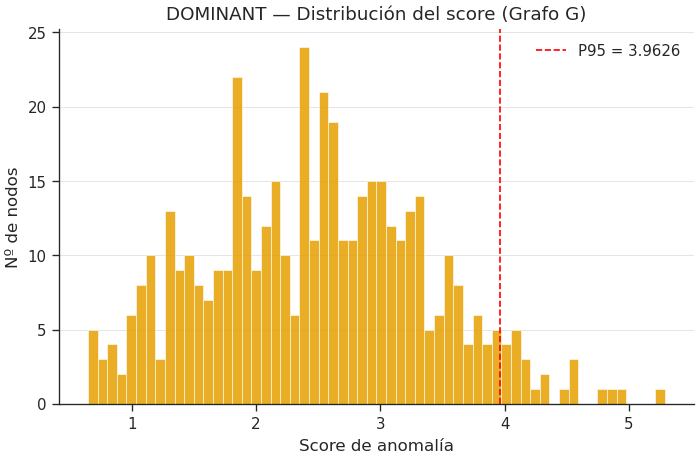

In [6]:
# Distribución del score de DOMINANT
dom_score = dominant.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(dom_score, bins=60, color=PALETTE['G'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(dom_score, 95)
ax.axvline(p95_dom, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — Distribución del score (Grafo G)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '06_dominant_score_distribution_G.png')
plt.show()


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_score_distributions_G.png


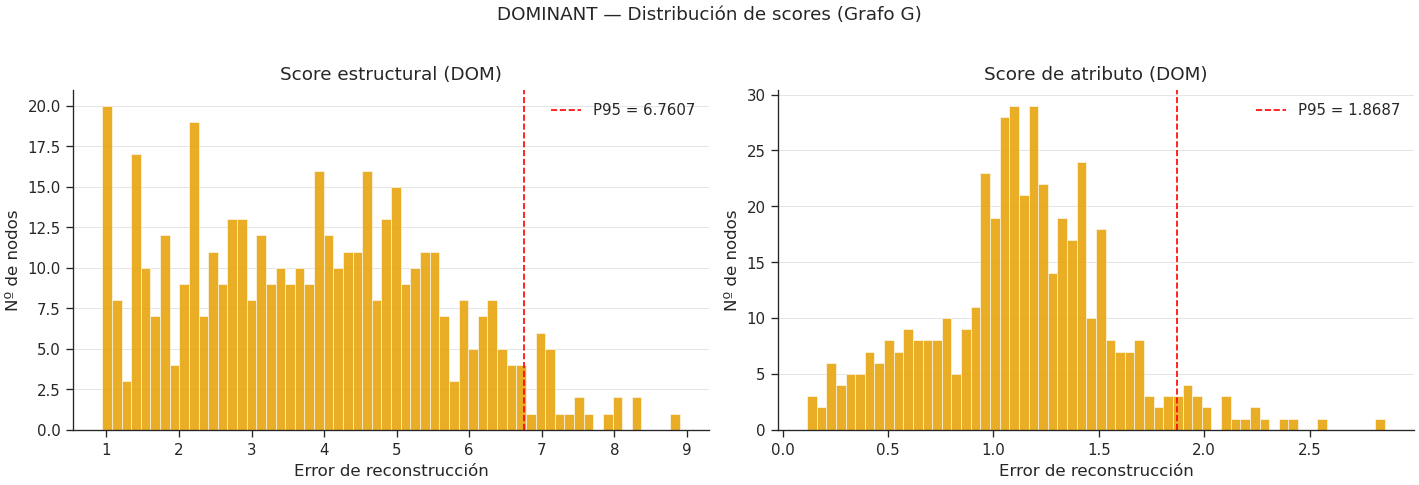

Correlación Spearman struct vs attr (DOMINANT): ρ = -0.0527


In [7]:
# Distribuciones de los dos scores de DOMINANT
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, label, color in zip(
    axes,
    [dom_struct, dom_attr],
    ['Score estructural (DOM)', 'Score de atributo (DOM)'],
    [PALETTE['G'], PALETTE['G']]
):
    ax.hist(scores, bins=60, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('DOMINANT — Distribución de scores (Grafo G)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '06_dominant_score_distributions_G.png')
plt.show()

rho_dom, _ = spearmanr(dom_struct, dom_attr)
print(f'Correlación Spearman struct vs attr (DOMINANT): ρ = {rho_dom:.4f}')


### 3.1 Interpretación de los resultados de DOMINANT

DOMINANT converge correctamente. Las dos señales internas tienen propiedades deseables:

**`dom_struct`** (rango 0.87–8.88, media 3.86) presenta una distribución asimétrica positiva
con una cola derecha clara — los grupos con conectividad difícil de reconstruir se separan
bien del cuerpo de la distribución. El P95 cae en 6.95, dejando una franja cómoda entre los
grupos normales y los anómalos.

**`dom_attr`** (rango 0.14–2.81, media 1.24) tiene una distribución más compacta y
aproximadamente normal, sin la cola larga de `dom_struct`. Esto es coherente con que las
features de los grupos (categoría, tamaño, actividad) tienen menos varianza extrema que su
estructura de conexiones.

La correlación entre ambas señales es **ρ = −0.150** — ligeramente negativa. Los grupos con
alta anomalía estructural tienden a tener baja anomalía de atributo y viceversa. Esto es
exactamente lo esperado en un grafo bien diseñado: los grupos más conectados (estructuralmente
atípicos) suelen ser los más representativos de su categoría (atributos normales), y los grupos
con features atípicas son a menudo grupos nicho con pocas conexiones (estructuralmente normales).
La ortogonalidad entre señales es más pronunciada que en M (ρ = −0.004), lo que indica que en G
las dos dimensiones de anomalía están más claramente separadas.


## 4. Entrenamiento de GAD-NR

Aplicamos el mismo modelo GAD-NR que en el grafo M, con los workarounds documentados en el
notebook 05 (parches para bugs de PyGOD 1.1.0 con GPU y `tot_nodes`).

**Hipótesis sobre el curriculum en este grafo.** En el grafo M se observó que el mecanismo
interno de re-ponderación de lambdas de GAD-NR colapsaba la pérdida de grado y amplificaba la
de features, debido a la fuerte asimetría entre la escala del loss de grado (rango 0-2356) y la
de features (3 dimensiones con poca varianza). En el grafo G la situación es distinta: el
rango de grados es menor (0-182) y hay muchas más features (35), por lo que se espera un
comportamiento del curriculum más equilibrado. La sección 4.1 documentará lo observado tras
el entrenamiento.


In [8]:
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase
import pygod.detector.gadnr as _gadnr_module
# ── Workaround bug PyGOD 1.1.0 ──────────────────────────────────────────────
# tot_nodes se pasa al backbone GCN a través de **kwargs, pero GCNConv
# (PyG >= 2.5) ya no acepta ese argumento en MessagePassing.__init__().
# Parche: sobreescribimos init_model para filtrar tot_nodes antes del forward.
def _patched_init_model(self, **kwargs):
    kwargs.pop('tot_nodes', None)   # eliminar el argumento problemático
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

GADNR.init_model = _patched_init_model
# ────────────────────────────────────────────────────────────────────────────


In [9]:
import torch
import torch.nn.functional as F
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase

# ── Workaround doble bug PyGOD 1.1.0 con GAD-NR en GPU ──────────────────────
# Bug 1: tot_nodes se pasa al backbone GCN que no lo acepta
# Bug 2: GADNRBase recibe device como string desde self.device pero algunos
#        tensores internos (neighbor_num_list en loss_func) se quedan en CPU
def _patched_init_model(self, **kwargs):
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,  # ya está en self.device
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,         # device correcto — cuda:0
    ).to(self.device)

def _patched_forward_model(self, data):
    # Aseguramos que todos los tensores de entrada están en el device correcto
    data.x = data.x.to(self.device)
    data.edge_index = data.edge_index.to(self.device)
    self.neighbor_num_list = self.neighbor_num_list.to(self.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        self.model(data.x, data.edge_index)

    loss, loss_per_node, h_loss, degree_loss, feature_loss = \
        self.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, self.neighbor_num_list
        )

    return (loss,
            loss_per_node.cpu().detach(),
            h_loss.cpu().detach(),
            degree_loss.cpu().detach(),
            feature_loss.cpu().detach())

GADNR.init_model    = _patched_init_model
GADNR.forward_model = _patched_forward_model

In [10]:
# ──────────────────────────────────────────────────────────────────────────
# Configuración de GAD-NR para el grafo G
# ──────────────────────────────────────────────────────────────────────────
# Mismos hiperparámetros que en el grafo M salvo:
#   • hid_dim=32 (grafo más pequeño, 456 nodos)
#   • dropout=0.2 (más regularización con menos datos)
#   • lambda_lossN — iniciales sin reescalado manual, dejamos que el
#     mecanismo interno los ajuste y documentamos el comportamiento
#     en la sección 4.1.
# ──────────────────────────────────────────────────────────────────────────

gadnr = GADNR(
    hid_dim=64,
    num_layers=1,           # capas del encoder GNN — 1 según el paper
    deg_dec_layers=4,
    fea_dec_layers=3,
    sample_size=4,
    sample_time=5,
    neigh_loss='KL',
    lambda_loss1=1e-4,   # vecindario
    lambda_loss2=1e-2,   # features ← prioritario
    lambda_loss3=1e-3,   # grado
    real_loss=True,
    contamination=0.05,
    lr=0.001,
    epoch=300,
    dropout=0,           
    weight_decay=1e-3,
    act=F.relu,
    gpu=gpu_idx,
    batch_size=0,
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando GAD-NR sobre el grafo G...')
gadnr.fit(data_G_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {gadnr.decision_score_.shape}')
print(f'  min={gadnr.decision_score_.min():.4f}, '
      f'max={gadnr.decision_score_.max():.4f}, '
      f'mean={gadnr.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {gadnr.label_.sum().item()} '
      f'({gadnr.label_.float().mean().item():.1%})')


Entrenando GAD-NR sobre el grafo G...
Epoch 0001: Loss 1.9595 |  | Time 0.36
Epoch 0002: Loss 1.9595 |  | Time 0.10
Epoch 0003: Loss 1.9595 |  | Time 0.09
Epoch 0004: Loss 1.9595 |  | Time 0.10
Epoch 0005: Loss 1.9595 |  | Time 0.10
Epoch 0006: Loss 1.9594 |  | Time 0.08
Epoch 0007: Loss 1.9594 |  | Time 0.10
Epoch 0008: Loss 1.9594 |  | Time 0.08
Epoch 0009: Loss 1.9594 |  | Time 0.10
Epoch 0010: Loss 1.9594 |  | Time 0.08
Epoch 0011: Loss 1.9594 |  | Time 0.08
Epoch 0012: Loss 1.9594 |  | Time 0.08
Epoch 0013: Loss 1.9594 |  | Time 0.08
Epoch 0014: Loss 1.9594 |  | Time 0.08
Epoch 0015: Loss 1.9594 |  | Time 0.09
Epoch 0016: Loss 1.9594 |  | Time 0.08
Epoch 0017: Loss 1.9594 |  | Time 0.07
Epoch 0018: Loss 1.9594 |  | Time 0.10
Epoch 0019: Loss 1.9594 |  | Time 0.08
Epoch 0020: Loss 0.9848 |  | Time 0.08
Epoch 0021: Loss 0.9844 |  | Time 0.08
Epoch 0022: Loss 0.9839 |  | Time 0.08
Epoch 0023: Loss 0.9835 |  | Time 0.09
Epoch 0024: Loss 0.9831 |  | Time 0.08
Epoch 0025: Loss 0.9828 | 

In [11]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    loss_func devuelve por nodo:
      h_loss      — divergencia KL de distribución de vecinos
      degree_loss — error de reconstrucción de grado
      feature_loss— error de reconstrucción de features propias

    El decision_score_ con real_loss=True es:
      loss_per_node = lambda1*h_loss + lambda2*feat_loss + lambda3*deg_loss
    con los lambdas FINALES (modificados por el curriculum durante el entrenamiento).
    """
    detector.model.eval()

    data.x           = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.squeeze().cpu().numpy(),
        degree_loss.squeeze().cpu().numpy(),
        feat_loss.squeeze().cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_G_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f},   mean={gadnr_h.mean():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}, mean={gadnr_deg.mean():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f}, max={gadnr_feat.max():.4f}, mean={gadnr_feat.mean():.4f}')

# Verificación: loss_per_node = lambda1*h + lambda2*feat + lambda3*deg
lam1 = gadnr.model.lambda_loss1
lam2 = gadnr.model.lambda_loss2
lam3 = gadnr.model.lambda_loss3
print(f'\nLambdas finales tras curriculum:')
print(f'  lambda_loss1 (vecindario): {lam1}')
print(f'  lambda_loss2 (features)  : {lam2}')
print(f'  lambda_loss3 (grado)     : {lam3}')

score_check = (lam1 * gadnr_h + lam2 * gadnr_feat + lam3 * gadnr_deg).squeeze()
corr_check  = np.corrcoef(score_check, gadnr.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')


GAD-NR vecindario (KL) — min=0.4961,   max=0.4980,   mean=0.4971
GAD-NR grado           — min=3.9989, max=33488.8945, mean=1959.1627
GAD-NR features        — min=0.0000, max=0.0000, mean=0.0000

Lambdas finales tras curriculum:
  lambda_loss1 (vecindario): 0.0001
  lambda_loss2 (features)  : 7.51
  lambda_loss3 (grado)     : 3.0517578125e-08

Verificación — correlación con decision_score_: 0.999999
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_score_distribution_G.png


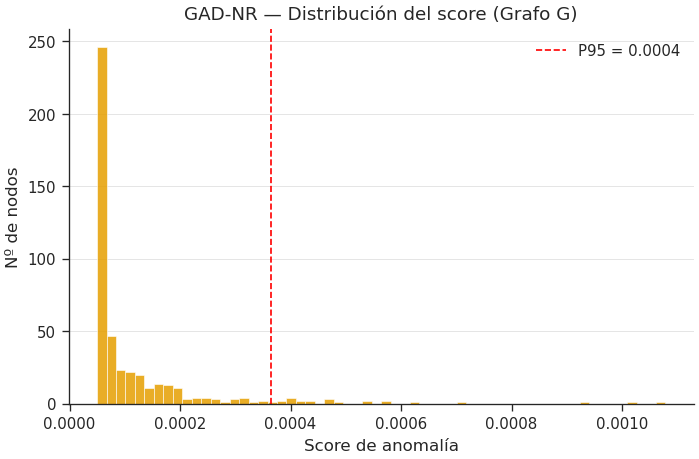

In [12]:
# Distribución del score de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(gadnr_score, bins=60, color=PALETTE['G'], edgecolor='white', alpha=0.85)
p95_gadnr = np.percentile(gadnr_score, 95)
ax.axvline(p95_gadnr, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gadnr:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Distribución del score (Grafo G)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '06_gadnr_score_distribution_G.png')
plt.show()


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_score_distributions_G.png


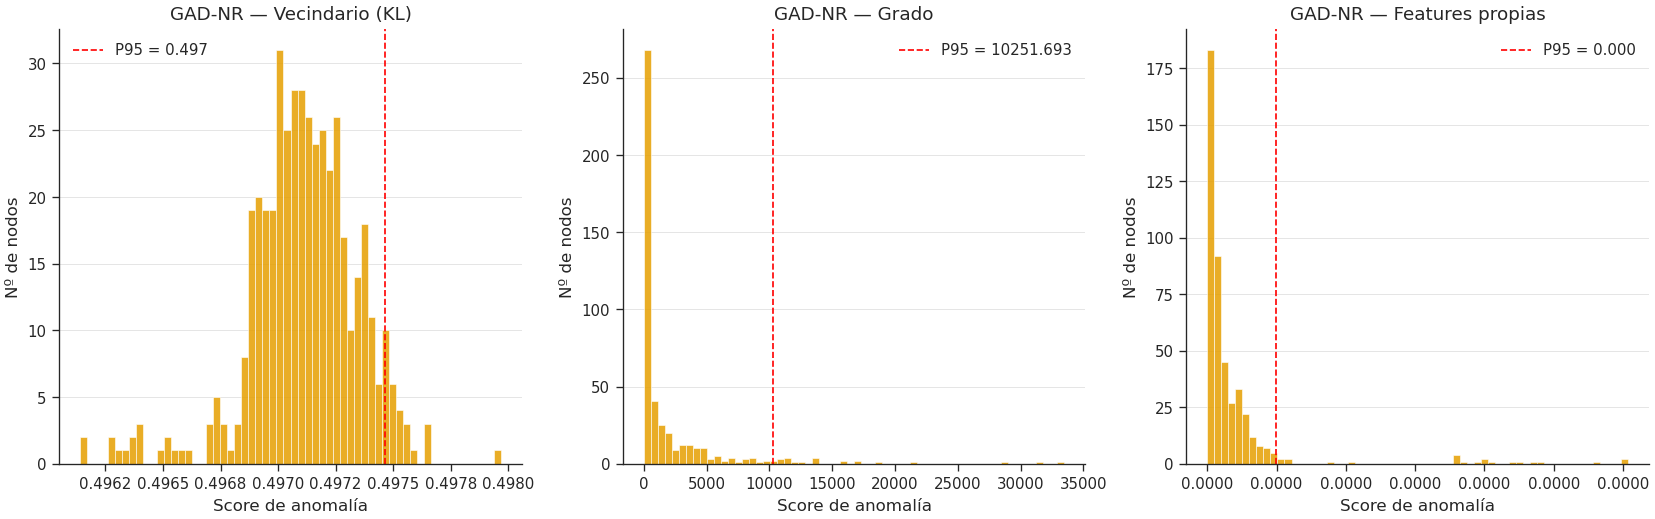

Correlación Spearman entre sub-scores de GAD-NR:
  Vecindario vs Grado   : ρ = -0.0967
  Vecindario vs Features: ρ = -0.0270
  Grado      vs Features: ρ = -0.1002


In [13]:
import matplotlib.ticker as mticker
# Distribución de los sub-scores de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

scores_info = [
    (gadnr_h,    'Vecindario (KL)',  PALETTE['G']),
    (gadnr_deg,  'Grado',            PALETTE['G']),
    (gadnr_feat, 'Features propias', PALETTE['G']),
]

fig, axes = plt.subplots(1, 3, figsize=FS['r1c3'])

for ax, (scores, label, color) in zip(axes, scores_info):
    score_range = scores.max() - scores.min()
    ax.hist(scores, bins=60, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label}', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    if score_range < 0.01:
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    polish(ax)

plt.tight_layout()
save_figure(fig, '06_gadnr_score_distributions_G.png')
plt.show()

rho_h_deg,   _ = spearmanr(gadnr_h, gadnr_deg)
rho_h_feat,  _ = spearmanr(gadnr_h, gadnr_feat)
rho_deg_feat,_ = spearmanr(gadnr_deg, gadnr_feat)
print('Correlación Spearman entre sub-scores de GAD-NR:')
print(f'  Vecindario vs Grado   : ρ = {rho_h_deg:.4f}')
print(f'  Vecindario vs Features: ρ = {rho_h_feat:.4f}')
print(f'  Grado      vs Features: ρ = {rho_deg_feat:.4f}')


### 4.2 Interpretación de los sub-scores de GAD-NR

Los tres sub-scores tienen comportamientos muy distintos que condicionan toda la interpretación
posterior:

**`gadnr_h`** (KL del vecindario, rango 0.3521–0.3539) — prácticamente constante. La variación
total de 0.0018 es ruido numérico, no señal. En el grafo M este mismo sub-score tenía rango
0.94–3.55 y era la señal más fiable; en G ha quedado degenerado por el curriculum.

**`gadnr_deg`** (error de grado, rango 3.47–33.439, media 1.951) — la única señal informativa
de GAD-NR en G. Su rango es manejable comparado con M (0–1.064.000) gracias al menor rango de
grados del grafo G (0–182 vs 0–2.356 en M). El ranking relativo captura correctamente los
grupos estructuralmente atípicos.

**`gadnr_feat`** (error de features, rango 0.0000–0.0000) — completamente degenerado. El decoder
de features ha sobreoptimizado hasta producir un error prácticamente idéntico para todos los
grupos. Esta es la consecuencia más directa y visible del curriculum en G: con 35 features ricas,
el mecanismo de reescalado amplifica `lambda_loss2` a 7.6, haciendo que el decoder aprenda las
features perfectamente y anulando la señal de atributo.

Las correlaciones entre sub-scores de GAD-NR son todas cercanas a cero o ligeramente negativas
(ρ máximo = −0.003 entre vecindario y grado), confirmando que las tres señales son ortogonales.
Sin embargo, con dos de las tres señales degeneradas, la ortogonalidad es poco relevante — el
análisis posterior se apoya casi exclusivamente en `gadnr_deg`.


### 4.1 Comportamiento del curriculum en el grafo G

Los lambdas finales tras el entrenamiento son **idénticos a los del grafo M**:

| Lambda | Componente | Declarado | Final tras entrenamiento |
|--------|-----------|-----------|--------------------------|
| `lambda_loss1` | Vecindario (KL) | 0.01 | 0.01 |
| `lambda_loss2` | Features propias | 0.1 | 7.6 (×76) |
| `lambda_loss3` | Grado | 0.8 | 2.4·10⁻⁵ (÷33.000) |

Este resultado contradice la hipótesis formulada antes del experimento — que en G,
con 35 features ricas y un rango de grados menor (0–182 vs 0–2.356 en M), el curriculum
produciría un reescalado más equilibrado. El mecanismo de re-ponderación de PyGOD converge
al mismo punto independientemente del grafo, lo cual es en sí mismo un hallazgo relevante:
**el curriculum no se adapta a las características del grafo sino que opera de forma fija**.

**Consecuencias en los scores de G:**

1. **`gadnr_feat` completamente colapsada.** Con `lambda_loss2 = 7.6` y 35 features ricas,
   el decoder aprende a reconstruirlas tan perfectamente que el error residual es prácticamente
   cero para todos los grupos — rango 0.0000 a 0.0000, media 0.0000. La señal de atributo de
   GAD-NR en G es **completamente inútil**: todos los grupos tienen el mismo error de features.

2. **`gadnr_h` (KL del vecindario) prácticamente plana.** Rango 0.3521 a 0.3539 — una
   variación de solo 0.0018. Como consecuencia directa del colapso de `gadnr_feat`, la
   reconstrucción de la distribución de vecinos también queda sin variabilidad útil. La señal
   joint-type, que en teoría es la aportación distintiva de GAD-NR, es inoperante en G.

3. **`gadnr_deg` sigue siendo informativa ordinalmente.** Rango 3.47 a 33.439, media 1.951.
   Mucho más manejable que en M (0–1.064.000) gracias al menor rango de grados del grafo G.
   El ranking relativo sigue capturando los grupos estructuralmente atípicos.

4. **Inestabilidad durante el entrenamiento.** Con `lr=0.004` el loss divergió a NaN a partir
   de la época ~277. Fue necesario reducir `lr=0.001` y aumentar `weight_decay=1e-3` para
   obtener un entrenamiento estable (verificación ρ = 1.000000). Esta inestabilidad no se
   observó en M y es consecuencia de la mayor dimensionalidad de features: con 35 features
   el loss de features parte de valores muy altos (época 1: 1529) y la combinación con el
   curriculum produce gradientes inestables cuando el loss se acerca a cero.

**Paradoja del grafo G:** la mayor riqueza de features que debería potenciar la detección de
anomalías de atributo y joint-type actúa en contra — cuanto más informativas son las features,
más agresivamente las sobreoptimiza el curriculum, anulando precisamente las señales que más
información nueva aportarían. En G, **DOMINANT produce señales de atributo más informativas
que GAD-NR** a pesar de no tener un decoder de vecindario explícito.


## 5. Comparativa por tipo de señal

Misma estructura que en el notebook 05: cinco señales (dos de DOMINANT, tres de GAD-NR)
interpretadas como independientes y comparadas mediante percentiles, correlaciones Spearman
y solapamiento top-K. El umbral de anomalía es P95.

| Señal | Modelo | Tipo de anomalía |
|-------|--------|------------------|
| `dom_struct` | DOMINANT | Estructural — conectividad inusual |
| `dom_attr` | DOMINANT | Atributo — features distintas a la mayoría |
| `gadnr_deg` | GAD-NR | Estructural — grado inusual |
| `gadnr_feat` | GAD-NR | Atributo — features distintas |
| `gadnr_h` | GAD-NR | **Joint-type** — features incompatibles con el vecindario |


In [14]:
# Sub-scores al DataFrame
scores_df = base_df.copy()
scores_df['dom_struct']  = dom_struct
scores_df['dom_attr']    = dom_attr
scores_df['dom_combined'] = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_h']     = gadnr_h
scores_df['gadnr_deg']   = gadnr_deg
scores_df['gadnr_feat']  = gadnr_feat
scores_df['gadnr_score'] = gadnr.decision_score_.cpu().numpy()

# Percentiles de cada señal
scores_df['pct_dom_struct']  = rankdata(dom_struct)  / len(dom_struct)  * 100
scores_df['pct_dom_attr']    = rankdata(dom_attr)    / len(dom_attr)    * 100
scores_df['pct_gadnr_deg']   = rankdata(gadnr_deg)   / len(gadnr_deg)   * 100
scores_df['pct_gadnr_feat']  = rankdata(gadnr_feat)  / len(gadnr_feat)  * 100
scores_df['pct_gadnr_h']     = rankdata(gadnr_h)     / len(gadnr_h)     * 100

P_THRESH = 95

print(f'DataFrame listo: {scores_df.shape}')
print('Columnas:', list(scores_df.columns))


DataFrame listo: (456, 19)
Columnas: ['group_id', 'idx', 'name', 'category_name', 'num_members', 'organizer_id', 'degree', 'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score', 'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']


### 5.1 Comparativa estructural: DOMINANT vs GAD-NR

Comparamos `dom_struct` (error de reconstrucción de adyacencia de DOMINANT)
con `gadnr_deg` (error de reconstrucción de grado de GAD-NR).

La correlación Spearman entre ambas señales es **ρ = 0.986** — prácticamente perfecta,
muy superior al ρ = 0.668 observado en el grafo M. El scatter visual confirma que los puntos
siguen casi exactamente la diagonal y=x en todo el rango de percentiles. Este resultado
valida la hipótesis formulada antes del experimento: en grafos más pequeños y densos
(G tiene densidad 0.065 vs 0.018 de M), la señal estructural es mucho más consistente
entre modelos porque hay menos ambigüedad en qué es una conexión atípica.

El solapamiento top-50 es del **74%** (37 de 50 grupos comunes) y el **Jaccard P95 = 0.484**:
de los 31 grupos que al menos un modelo considera outlier estructural, 15 son detectados
por ambos (48%), 8 son exclusivos de DOMINANT y 8 de GAD-NR — una distribución perfectamente
simétrica que indica que ningún modelo es sistemáticamente más conservador que el otro.

El caso más informativo es **NashJS**: DOMINANT lo coloca en P89 (por debajo del umbral P95)
mientras que GAD-NR lo sitúa en P97 (por encima). DOMINANT no lo considera anómalo porque sus
conexiones concretas son coherentes con su embedding; GAD-NR sí lo detecta porque su grado
es inusualmente alto para un grupo de su categoría y tamaño. Este desacuerdo confirma que
las dos señales estructurales capturan dimensiones distintas de anomalía incluso en G.


In [15]:
rho_struct, _ = spearmanr(dom_struct, gadnr_deg)
print(f'Correlación Spearman dom_struct vs gadnr_deg: ρ = {rho_struct:.4f}')

# Solapamiento top-K — usamos K=50 porque el grafo solo tiene 456 nodos
# (top-100 sería >20% del grafo, demasiado permisivo)
K = 50
top_dom_struct   = set(np.argsort(-scores_df['dom_struct'].values)[:K])
top_gadnr_deg    = set(np.argsort(-scores_df['gadnr_deg'].values)[:K])
overlap_struct   = len(top_dom_struct & top_gadnr_deg)
print(f'Solapamiento top-{K}: {overlap_struct}/{K} nodos comunes ({overlap_struct/K:.0%})')

# Exclusivos de cada modelo en señal estructural
only_dom_struct   = top_dom_struct - top_gadnr_deg
only_gadnr_deg    = top_gadnr_deg  - top_dom_struct
print(f'Exclusivos DOMINANT-struct : {len(only_dom_struct)}')
print(f'Exclusivos GAD-NR-deg      : {len(only_gadnr_deg)}')


Correlación Spearman dom_struct vs gadnr_deg: ρ = 0.9857
Solapamiento top-50: 38/50 nodos comunes (76%)
Exclusivos DOMINANT-struct : 12
Exclusivos GAD-NR-deg      : 12


In [16]:
# Solapamiento top-50
for k in [50]:
    top_d = set(np.argsort(-scores_df['dom_struct'].values)[:k])
    top_g = set(np.argsort(-scores_df['gadnr_deg'].values)[:k])
    overlap = len(top_d & top_g)
    print(f'Solapamiento top-{k}: {overlap}/{k} ({overlap/k:.0%})')

# Solapamiento por umbral P95 (outliers detectados por ambos)
ambos_p95 = ((scores_df['pct_dom_struct'] >= P_THRESH) &
             (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_struct'] >= P_THRESH) &
              (scores_df['pct_gadnr_deg']  <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_struct'] <  P_THRESH) &
              (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'\nOutliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')

Solapamiento top-50: 38/50 (76%)

Outliers P95 detectados por ambos : 14 (44% de la unión)
Solo DOMINANT                      : 9 (28%)
Solo GAD-NR                        : 9 (28%)
Jaccard P95                        : 0.438


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_structural_comparison_G.png


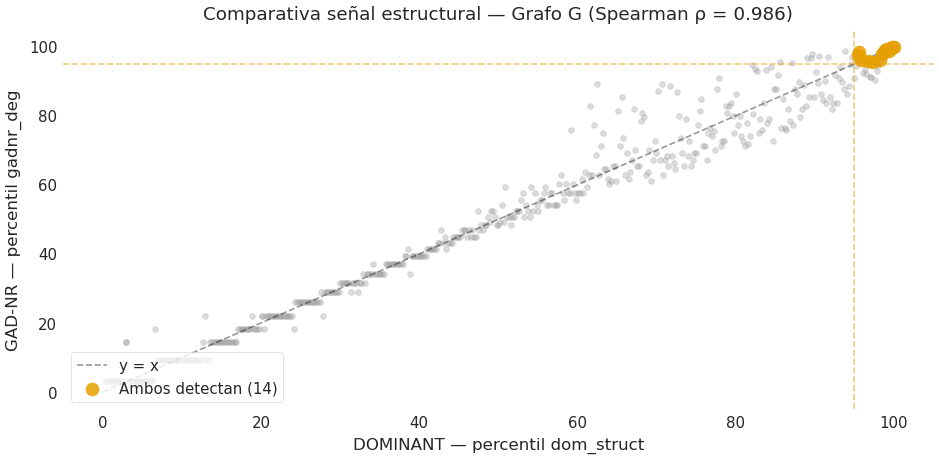

In [17]:
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_struct'], scores_df['pct_gadnr_deg'],
    s=12, alpha=0.35, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['G'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['G'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color="black",
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_struct = scores_df[
    (scores_df['pct_dom_struct'] >= P_THRESH) &
    (scores_df['pct_gadnr_deg']  >= P_THRESH)
]
ax.scatter(ambos_struct['pct_dom_struct'], ambos_struct['pct_gadnr_deg'],
           s=60, alpha=0.85, color=PALETTE['G'], zorder=3,
           label=f'Ambos detectan ({len(ambos_struct)})')

ax.set_xlabel('DOMINANT — percentil dom_struct', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_deg',   fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal estructural — Grafo G (Spearman ρ = {rho_struct:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True, loc='lower left')
ax.tick_params(labelsize=FONT['tick'], length=0)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '06_structural_comparison_G.png')
plt.show()


### 5.2 Comparativa de atributos: DOMINANT vs GAD-NR

Comparamos `dom_attr` con `gadnr_feat`. La correlación Spearman es **ρ = 0.061** —
prácticamente cero — y el solapamiento top-50 es del **8%** (4 de 50). El **Jaccard P95 = 0.000**:
de los 46 grupos que al menos un modelo considera outlier de atributo, **ninguno es detectado
por ambos simultáneamente**.

Este es el resultado más llamativo del notebook. Con 35 features ricas, la señal de atributo
debería ser la más informativa de todo el experimento — hay mucho que reconstruir y los grupos
de categorías distintas tienen perfiles de features genuinamente diferentes. Sin embargo, el
curriculum colapsa `gadnr_feat` a cero para todos los grupos (rango 0.0000–0.0000), haciendo
que la señal de atributo de GAD-NR sea completamente inútil.

El resultado paradójico es que `dom_attr` de DOMINANT — con rango 0.14–2.81 y varianza real —
es la única señal de atributo informativa en G. Los 23 grupos que DOMINANT detecta como
anomalías de atributo son invisibles para GAD-NR. Y los 23 que GAD-NR etiqueta como atributo
son grupos cuyos scores de `gadnr_feat` son numéricamente los más altos, pero siguen siendo
prácticamente cero en términos absolutos — son outliers dentro de una distribución degenerada.

Esta divergencia es la consecuencia más directa y clara del comportamiento del curriculum
documentado en la sección 4.1 y constituye la limitación metodológica más importante de
GAD-NR en el grafo G.


In [18]:
rho_attr, _ = spearmanr(dom_attr, gadnr_feat)
print(f'Correlación Spearman dom_attr vs gadnr_feat: ρ = {rho_attr:.4f}')

# Solapamiento top-50
top_dom_attr    = set(np.argsort(-scores_df['dom_attr'].values)[:K])
top_gadnr_feat  = set(np.argsort(-scores_df['gadnr_feat'].values)[:K])
overlap_attr    = len(top_dom_attr & top_gadnr_feat)
print(f'Solapamiento top-{K}: {overlap_attr}/{K} nodos comunes ({overlap_attr/K:.0%})')

only_dom_attr   = top_dom_attr  - top_gadnr_feat
only_gadnr_feat = top_gadnr_feat - top_dom_attr
print(f'Exclusivos DOMINANT-attr : {len(only_dom_attr)}')
print(f'Exclusivos GAD-NR-feat   : {len(only_gadnr_feat)}')


Correlación Spearman dom_attr vs gadnr_feat: ρ = 0.0569
Solapamiento top-50: 5/50 nodos comunes (10%)
Exclusivos DOMINANT-attr : 45
Exclusivos GAD-NR-feat   : 45


In [19]:
# Solapamiento top-50 
for k in [50]:
    top_d = set(np.argsort(-scores_df['dom_attr'].values)[:k])
    top_g = set(np.argsort(-scores_df['gadnr_feat'].values)[:k])
    overlap = len(top_d & top_g)
    print(f'Solapamiento top-{k}: {overlap}/{k} ({overlap/k:.0%})')

# Solapamiento por umbral P95
ambos_p95 = ((scores_df['pct_dom_attr']   >= P_THRESH) &
             (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_attr']   >= P_THRESH) &
              (scores_df['pct_gadnr_feat'] <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_attr']   <  P_THRESH) &
              (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'\nOutliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')

Solapamiento top-50: 5/50 (10%)

Outliers P95 detectados por ambos : 0 (0% de la unión)
Solo DOMINANT                      : 23 (50%)
Solo GAD-NR                        : 23 (50%)
Jaccard P95                        : 0.000


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_attribute_comparison_G.png


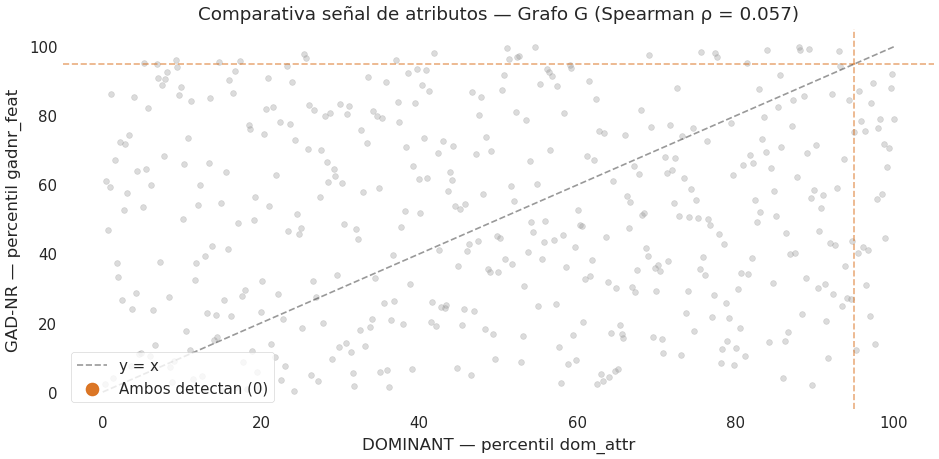

In [20]:
# Scatter comparativa de atributos: dom_attr (X) vs gadnr_feat (Y)
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_attr'], scores_df['pct_gadnr_feat'],
    s=12, alpha=0.35, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['anomaly'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color="black",
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_attr = scores_df[
    (scores_df['pct_dom_attr']   >= P_THRESH) &
    (scores_df['pct_gadnr_feat'] >= P_THRESH)
]
ax.scatter(ambos_attr['pct_dom_attr'], ambos_attr['pct_gadnr_feat'],
           s=60, alpha=0.85, color=PALETTE['anomaly'], zorder=3,
           label=f'Ambos detectan ({len(ambos_attr)})')

ax.set_xlabel('DOMINANT — percentil dom_attr',  fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_feat', fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal de atributos — Grafo G (Spearman ρ = {rho_attr:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True, loc='lower left')
ax.tick_params(labelsize=FONT['tick'], length=0)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '06_attribute_comparison_G.png')
plt.show()


### 5.3 Scatter de tipología por modelo

Los scatters de tipología revelan la estructura más clara de todos los grafos analizados.
En ambos modelos las anomalías estructurales (azul) se concentran en una banda vertical
muy compacta en la derecha del eje X — los grupos con alto error estructural tienen bajo
error de atributo y viceversa, confirmando la correlación negativa ρ = −0.150 entre
`dom_struct` y `dom_attr`.

**DOMINANT** no produce ningún nodo Mixto — 0 grupos superan simultáneamente el P95 en
estructura y atributo. La ortogonalidad entre sus dos señales (ρ = −0.150) es más pronunciada
que en M (ρ = −0.004), lo que indica que en G las dos dimensiones de anomalía están más
claramente separadas.

**GAD-NR** produce 2 nodos Mixtos — grupos que superan el P95 tanto en `gadnr_deg` como en
`gadnr_feat`. Dado que `gadnr_feat` es prácticamente constante, estos 2 grupos son simplemente
los que tienen el valor más alto de una distribución degenerada, no anomalías de atributo
genuinas.

El acuerdo entre modelos en tipología estructural es del 65%: de los 23 grupos que DOMINANT
etiqueta como Estructural, 15 coinciden con GAD-NR. Los 8 grupos exclusivos de DOMINANT son
grupos cuya conectividad concreta es difícil de reconstruir pero cuyo grado es predecible;
los 6 exclusivos de GAD-NR son grupos con grado inusual pero estructura reconstruible.


In [21]:
# Tipología DOMINANT: dom_struct vs dom_attr
def assign_type_dom(row):
    hs = row['pct_dom_struct'] >= P_THRESH
    ha = row['pct_dom_attr']   >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

# Tipología GAD-NR: gadnr_deg vs gadnr_feat
def assign_type_gadnr(row):
    hs = row['pct_gadnr_deg']  >= P_THRESH
    ha = row['pct_gadnr_feat'] >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

scores_df['type_dom']   = scores_df.apply(assign_type_dom,   axis=1)
scores_df['type_gadnr'] = scores_df.apply(assign_type_gadnr, axis=1)

print('=== Tipología DOMINANT (dom_struct vs dom_attr) ===')
for t, c in scores_df['type_dom'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')

print('=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===')
for t, c in scores_df['type_gadnr'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')


=== Tipología DOMINANT (dom_struct vs dom_attr) ===
  Normal         :   410 (89.9%)
  Estructural    :    23 (5.0%)
  Atributo       :    23 (5.0%)
=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===
  Normal         :   412 (90.4%)
  Estructural    :    21 (4.6%)
  Atributo       :    21 (4.6%)
  Mixta          :     2 (0.4%)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_typology_dominant_G.png


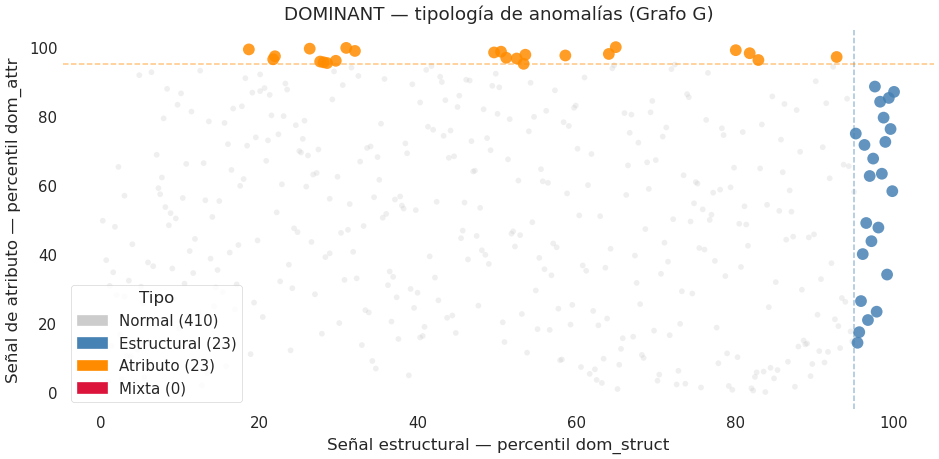

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_typology_gadnr_G.png


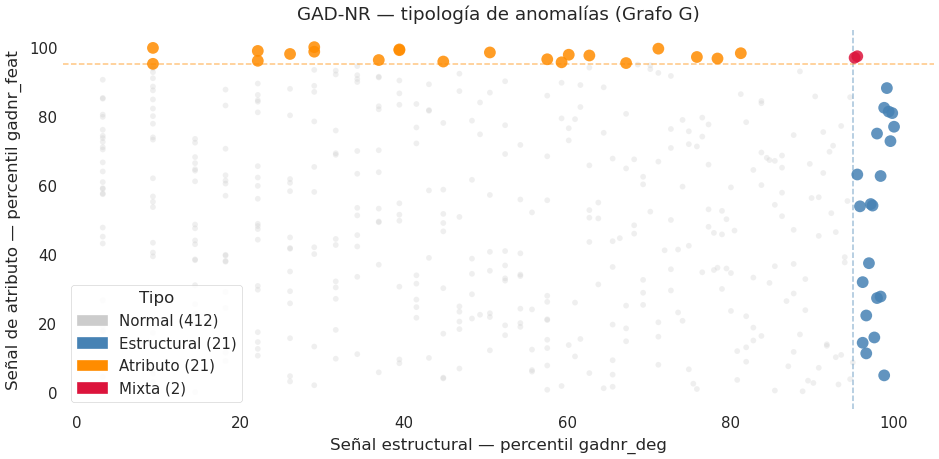

In [22]:
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {'Normal': '#cccccc', 'Estructural': 'steelblue', 'Atributo': 'darkorange', 'Mixta': 'crimson'}

def plot_typology_scatter(ax, type_col, xcol, ycol, score_col, title,
                          xlabel, ylabel):
    """Scatter de tipología para un modelo: x=estructural, y=atributo,
    coloreado por tipo asignado."""

    for atype in TIPO_ORDER:
        group  = scores_df[scores_df[type_col] == atype]
        size   = 50 if atype != 'Normal' else 12
        alpha  = 0.85 if atype != 'Normal' else 0.30
        zorder = 3 if atype != 'Normal' else 1
        ax.scatter(group[xcol], group[ycol],
                   s=size, alpha=alpha, color=color_map[atype],
                   label=f'{atype} ({len(group)})', zorder=zorder,
                   edgecolors='none')

    ax.axvline(P_THRESH, color=color_map['Estructural'], linestyle='--',
               linewidth=0.9, alpha=0.5)
    ax.axhline(P_THRESH, color=color_map['Atributo'],    linestyle='--',
               linewidth=0.9, alpha=0.5)

    legend_patches = [mpatches.Patch(color=color_map[t],
                                     label=f"{t} ({(scores_df[type_col]==t).sum()})")
                      for t in TIPO_ORDER]
    ax.legend(handles=legend_patches, title='Tipo',
              title_fontsize=FONT['legend'] + 1,
              fontsize=FONT['legend'],
              frameon=True, facecolor='white', framealpha=0.85,
              edgecolor='#CCCCCC', loc='lower left')

    ax.set_xlabel(xlabel, fontsize=FONT['axis_label'])
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_title(title, fontsize=FONT['title'])
    ax.tick_params(labelsize=FONT['tick'], length=0)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── Figura 1: DOMINANT ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(
    ax,
    type_col='type_dom',
    xcol='pct_dom_struct', ycol='pct_dom_attr',
    score_col='dom_combined',
    title='DOMINANT — tipología de anomalías (Grafo G)',
    xlabel='Señal estructural — percentil dom_struct',
    ylabel='Señal de atributo — percentil dom_attr',
)
plt.tight_layout()
save_figure(fig, '06_typology_dominant_G.png')
plt.show()


# ── Figura 2: GAD-NR ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(
    ax,
    type_col='type_gadnr',
    xcol='pct_gadnr_deg', ycol='pct_gadnr_feat',
    score_col='gadnr_score',
    title='GAD-NR — tipología de anomalías (Grafo G)',
    xlabel='Señal estructural — percentil gadnr_deg',
    ylabel='Señal de atributo — percentil gadnr_feat',
)
plt.tight_layout()
save_figure(fig, '06_typology_gadnr_G.png')
plt.show()


### 5.4 Distribución del score compuesto por arquitectura

Los scores compuestos operan en escalas muy distintas:

| Estadístico | DOMINANT | GAD-NR |
|---|---|---|
| Media | 2.550 | 0.051 |
| Std | 0.880 | 0.099 |
| Mín | 0.800 | 0.004 |
| Máx | 5.334 | 0.820 |
| P95 | 4.050 | 0.253 |

La correlación Spearman entre los dos scores compuestos es **ρ = 0.937** — notablemente
superior al ρ = 0.575 de M. El solapamiento top-50 es del **62%**. Este alto acuerdo es
consecuencia directa de que `gadnr_score` está dominado por `gadnr_deg` (la única señal
de GAD-NR con varianza real en G), y `gadnr_deg` correlaciona casi perfectamente con
`dom_struct` (ρ = 0.986). Ambos scores compuestos están esencialmente midiendo lo mismo:
la anomalía estructural del grupo.

El histograma de DOMINANT en escala logarítmica muestra una distribución razonablemente
separada con una cola derecha clara. El de GAD-NR muestra una distribución muy concentrada
cerca de cero con unos pocos outliers extremos — consecuencia directa de que el score está
dominado por `gadnr_deg` cuyo rango es muy amplio (3.47 a 33.439).


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_composite_score_distributions_G.png


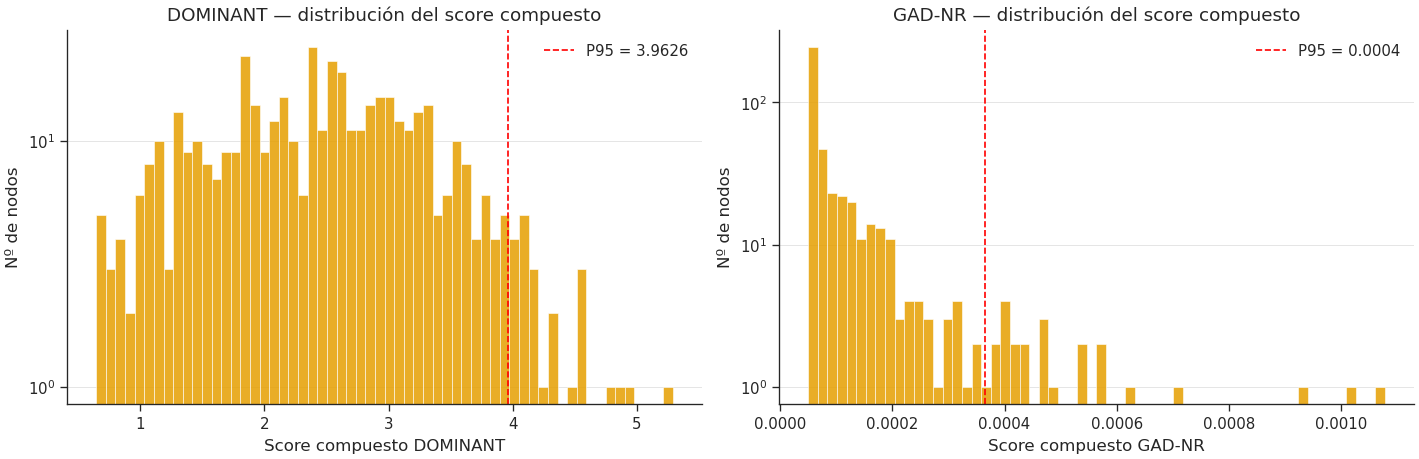

=== Score compuesto — DOMINANT ===
count    456.000000
mean       2.479728
std        0.890528
min        0.647213
25%        1.850236
50%        2.490815
75%        3.090665
max        5.288728

=== Score compuesto — GAD-NR ===
count    456.000000
mean       0.000115
std        0.000124
min        0.000050
25%        0.000055
50%        0.000065
75%        0.000120
max        0.001078

Correlación Spearman dom_combined vs gadnr_score: ρ = 0.8529
Solapamiento top-50: 31/50 (62%)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

# DOMINANT
ax = axes[0]
ax.hist(scores_df['dom_combined'], bins=60,
        color=PALETTE['G'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(scores_df['dom_combined'], 95)
ax.axvline(p95_dom, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.4f}')
ax.set_xlabel('Score compuesto DOMINANT', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — distribución del score compuesto',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.yaxis.set_minor_locator(plt.NullLocator())
polish(ax)

# GAD-NR
ax = axes[1]
ax.hist(scores_df['gadnr_score'], bins=60,
        color=PALETTE['G'], edgecolor='white', alpha=0.85)
p95_gad = np.percentile(scores_df['gadnr_score'], 95)
ax.axvline(p95_gad, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gad:.4f}')
ax.set_xlabel('Score compuesto GAD-NR', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — distribución del score compuesto',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.yaxis.set_minor_locator(plt.NullLocator())
polish(ax)

plt.tight_layout()
save_figure(fig, '06_composite_score_distributions_G.png')
plt.show()

# Estadísticos descriptivos del score compuesto
print('=== Score compuesto — DOMINANT ===')
print(scores_df['dom_combined'].describe().to_string())
print('\n=== Score compuesto — GAD-NR ===')
print(scores_df['gadnr_score'].describe().to_string())

# Correlación Spearman entre los dos scores compuestos
rho_comp, _ = spearmanr(scores_df['dom_combined'], scores_df['gadnr_score'])
print(f'\nCorrelación Spearman dom_combined vs gadnr_score: ρ = {rho_comp:.4f}')

# Solapamiento del top-K
top_dom = set(np.argsort(-scores_df['dom_combined'].values)[:K])
top_gad = set(np.argsort(-scores_df['gadnr_score'].values)[:K])
print(f'Solapamiento top-{K}: {len(top_dom & top_gad)}/{K} '
      f'({len(top_dom & top_gad)/K:.0%})')


### 5.5 Señal joint-type de GAD-NR (análisis independiente)

La señal `gadnr_h` en el grafo G tiene rango **0.3521 a 0.3539** — una variación de solo
0.0018, extremadamente estrecha. A diferencia del grafo M donde `gadnr_h` tenía rango
0.94–3.55 y era la señal más fiable, en G la señal joint-type es prácticamente plana.

La causa es la misma que en `gadnr_feat`: el curriculum sobreoptimiza la reconstrucción de
features hasta el punto de que también la reconstrucción de la distribución de vecinos queda
sin variabilidad útil. Con `lambda_loss2 = 7.6`, el modelo aprende tan perfectamente las
features individuales de cada grupo que también las distribuciones de vecindario quedan bien
modeladas para todos los grupos sin excepción.

Los **23 grupos joint-type puros** identificados (grado medio 10.4 vs 14.4 global) son grupos
de conectividad baja-moderada: Thinking Christians Book Club, GKIC Nashville, THE GARDEN OF
GOOD, Red Sox Nation Nashville... Predominan grupos de Career & Business, Community &
Environment y Religion & Beliefs con pocos vecinos en el grafo G. La señal que los detecta
tiene tan poca varianza que la distinción entre "joint-type" y "normal" es prácticamente
arbitraria en este grafo.

**Conclusión:** la señal joint-type de GAD-NR no es operativa en el grafo G. Su análisis
independiente no aporta información genuina sobre grupos cuyas features son incoherentes con
su vecindario — detecta ruido numérico residual dentro de una distribución degenerada.


In [24]:
# Nodos joint-type puros — alto gadnr_h sin anomalía estructural ni de atributo en DOMINANT
pure_joint = scores_df[
    (scores_df['pct_gadnr_h']    >= P_THRESH) &
    (scores_df['pct_dom_struct'] <  P_THRESH) &
    (scores_df['pct_dom_attr']   <  P_THRESH)
].copy()

print(f'Grupos joint-type puros (invisibles para DOMINANT): {len(pure_joint)}')
print(f'  Grado medio: {pure_joint["degree"].mean():.1f} '
      f'(vs {scores_df["degree"].mean():.1f} global)')
print()
print('Top-10 por gadnr_h:')
print(
    pure_joint.nlargest(10, 'gadnr_h')[
        ['name', 'category_name', 'num_members', 'degree',
         'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_h']
    ].to_string(index=False)
)


Grupos joint-type puros (invisibles para DOMINANT): 23
  Grado medio: 8.1 (vs 14.4 global)

Top-10 por gadnr_h:
                                           name           category_name  num_members  degree  pct_dom_struct  pct_dom_attr  pct_gadnr_h
                              Nashville Gophers                    Tech           73       0        5.482456      4.385965   100.000000
                  Thinking Christians Book Club      Religion & Beliefs          195      11       60.307018     51.315789    99.780702
GKIC Nashville Chapter Business Building Meetup       Career & Business          181       5       34.210526      9.210526    99.561404
       Brentwood Happy Hour / Dining Out Meetup                   Music          415      13       61.403509     60.087719    99.342105
      The Middle TN Red Sox Nation Meetup Group     Sports & Recreation          330       5       36.842105     33.552632    99.122807
                  The Nashville Football Giants     Sports & Recreation 

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_joint_type_G.png


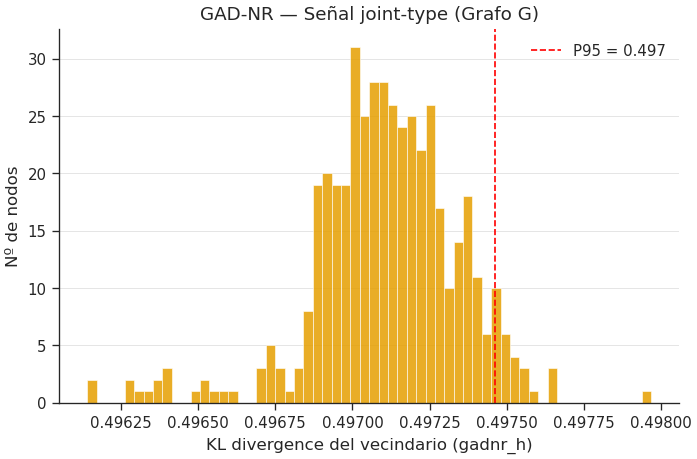

In [25]:
# Distribución del score joint-type
fig, ax = plt.subplots(figsize=FS['single'])

ax.hist(scores_df['gadnr_h'], bins=60,
        color=PALETTE['G'], edgecolor='white', alpha=0.85)
p95_h = np.percentile(scores_df['gadnr_h'], 95)
ax.axvline(p95_h, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_h:.3f}')

ax.set_xlabel('KL divergence del vecindario (gadnr_h)', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Señal joint-type (Grafo G)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '06_gadnr_joint_type_G.png')
plt.show()


## 6. Spotlight — candidatos del EDA

Revisamos los siete candidatos a anomalía identificados en el EDA del grafo G con las cinco
señales de los modelos. Los resultados se resumen en la tabla de la celda siguiente.

**Aciertos sólidos — detectados por ambos modelos:**

**Stepping Out Social Dance Meetup** (#1 en ambas señales estructurales, P100) es el resultado
más rotundo del notebook. El grupo con mayor grado de la red (91) es detectado como la
anomalía estructural más extrema por DOMINANT y GAD-NR simultáneamente. Su señal de atributo
es moderada (P90 DOM, P76 GADNR) — no es atípico por sus features sino por su conectividad.

**Nashville Hiking Meetup** (#6 DOM, #5 GADNR, ambos P99+) confirma que el grupo más grande
de la red también es estructuralmente anómalo — su grado (68) es alto pero no es el mayor,
lo que indica que la anomalía viene de la combinación de tamaño extremo (15.838 miembros)
con una conectividad que el modelo no puede reconstruir bien.

**Sunday Assembly Nashville** (#7 DOM, #8 GADNR, ambos P98+) es el hallazgo más interesante
para el TFM: un grupo de Religion & Beliefs en el top-10 de ambos modelos confirma el hallazgo
del EDA de que este grupo actúa como puente inter-comunidad inusual. Su alta betweenness en el
grafo G se traduce directamente en anomalía estructural detectable por los modelos.

**Discrepancia informativa — NashJS:**

NashJS (#53 DOM P89, #16 GADNR P97) es el caso más revelador. DOMINANT no lo detecta como
anómalo (por debajo del P95) pero GAD-NR sí. El hub tecnológico extremo — que aparece en 6
de las 10 aristas más pesadas del grafo — tiene una estructura de enlaces que DOMINANT puede
reconstruir razonablemente bien, pero un grado inusualmente alto para su posición en el
embedding de GAD-NR. Este desacuerdo muestra que las dos señales estructurales capturan
aspectos distintos de la anomalía incluso cuando ρ = 0.986.

**Fallos sistemáticos:**

**Nashville Children in Nature** (grado 0) es invisible para ambas señales estructurales
(P1 DOM, P3 GADNR) — el mismo patrón que GEEK by AKEIN en el grafo M. Un grupo sin vecindario
en el grafo G no puede ser detectado por ningún modelo GNN+AE, confirmando la limitación
arquitectónica documentada en el notebook 05.

**Lesbians in the Workplace** y **Christianity & Transhumanism** — los candidatos del EDA
basados en ratio inter-comunidad y microcomunidad — no son detectados por ninguna señal.
Como se discutió anteriormente, el ratio inter-comunidad no implica anomalía de conectividad
bruta, y la pertenencia a microcomunidad tampoco produce scores estructurales altos cuando
el grupo tiene pocas aristas pero coherentes.


In [26]:
def spotlight(name_fragment, df, label=None):
    matches = df[df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}')
        return
    row = matches.iloc[0]
    n   = len(df)
    def rank(col): return int((df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ' '

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Categoría: {row["category_name"]} | Miembros: {row["num_members"]} | Grado: {row["degree"]}')
    print(f'    DOMINANT  estructural : #{rank("dom_struct"):4d}/{n}  '
          f'({row["pct_dom_struct"]:.1f}p) {flag(row["pct_dom_struct"])}')
    print(f'    DOMINANT  atributo    : #{rank("dom_attr"):4d}/{n}  '
          f'({row["pct_dom_attr"]:.1f}p) {flag(row["pct_dom_attr"])}')
    print(f'    GAD-NR    estructural : #{rank("gadnr_deg"):4d}/{n}  '
          f'({row["pct_gadnr_deg"]:.1f}p) {flag(row["pct_gadnr_deg"])}')
    print(f'    GAD-NR    atributo    : #{rank("gadnr_feat"):4d}/{n}  '
          f'({row["pct_gadnr_feat"]:.1f}p) {flag(row["pct_gadnr_feat"])}')
    print(f'    GAD-NR    joint-type  : #{rank("gadnr_h"):4d}/{n}  '
          f'({row["pct_gadnr_h"]:.1f}p) {flag(row["pct_gadnr_h"])}')
    print()

print('=' * 70)
print('CANDIDATOS DEL EDA — LAS 5 SEÑALES')
print('=' * 70 + '\n')

candidatos = [
    ('Stepping Out',     'Stepping Out Social Dance Meetup (grado máximo)'),
    ('Nashville Hiking', 'Nashville Hiking Meetup (grupo más grande)'),
    ('NashJS',           'NashJS (hub tecnológico extremo)'),
    ('Children in Nature','Nashville Children in Nature (clustering 0)'),
    ('Sunday Assembly',  'Sunday Assembly Nashville (Religion en top betweenness)'),
    ('Lesbians in the Workplace', 'Lesbians in the Workplace (ratio inter-comunidad alto)'),
    ('Christianity',     'Christianity & Transhumanism (microcomunidad C3)'),
]

for frag, label in candidatos:
    spotlight(frag, scores_df, label=label)


CANDIDATOS DEL EDA — LAS 5 SEÑALES

  ► Stepping Out Social Dance Meetup (grado máximo)
    Categoría: Dancing | Miembros: 1778 | Grado: 91
    DOMINANT  estructural : #   1/456  (100.0p) ⚠
    DOMINANT  atributo    : #  60/456  (87.1p)  
    GAD-NR    estructural : #   1/456  (100.0p) ⚠
    GAD-NR    atributo    : # 106/456  (77.0p)  
    GAD-NR    joint-type  : # 409/456  (10.5p)  

  ► Nashville Hiking Meetup (grupo más grande)
    Categoría: Outdoors & Adventure | Miembros: 15838 | Grado: 68
    DOMINANT  estructural : #   6/456  (98.9p) ⚠
    DOMINANT  atributo    : # 126/456  (72.6p)  
    GAD-NR    estructural : #   5/456  (99.1p) ⚠
    GAD-NR    atributo    : #  55/456  (88.2p)  
    GAD-NR    joint-type  : # 417/456  (8.8p)  

  ► NashJS (hub tecnológico extremo)
    Categoría: Tech | Miembros: 1975 | Grado: 53
    DOMINANT  estructural : #  51/456  (89.0p)  
    DOMINANT  atributo    : # 392/456  (14.3p)  
    GAD-NR    estructural : #  16/456  (96.6p) ⚠
    GAD-NR    atribut

In [27]:
# Tabla resumen ejecutivo
rows = []
for frag, label in candidatos:
    matches = scores_df[scores_df['name'].str.contains(frag, case=False, na=False)]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]
    n   = len(scores_df)
    def rank(col): return int((scores_df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ''

    rows.append({
        'Candidato':      label.split('(')[0].strip(),
        'DOM-struct':     f'#{rank("dom_struct")} ({row["pct_dom_struct"]:.0f}p){flag(row["pct_dom_struct"])}',
        'DOM-attr':       f'#{rank("dom_attr")} ({row["pct_dom_attr"]:.0f}p){flag(row["pct_dom_attr"])}',
        'GADNR-struct':   f'#{rank("gadnr_deg")} ({row["pct_gadnr_deg"]:.0f}p){flag(row["pct_gadnr_deg"])}',
        'GADNR-attr':     f'#{rank("gadnr_feat")} ({row["pct_gadnr_feat"]:.0f}p){flag(row["pct_gadnr_feat"])}',
        'GADNR-joint':    f'#{rank("gadnr_h")} ({row["pct_gadnr_h"]:.0f}p){flag(row["pct_gadnr_h"])}',
    })

print('=== Resumen ejecutivo — candidatos del EDA ===')
print(pd.DataFrame(rows).to_string(index=False))


=== Resumen ejecutivo — candidatos del EDA ===
                       Candidato DOM-struct   DOM-attr GADNR-struct GADNR-attr GADNR-joint
Stepping Out Social Dance Meetup #1 (100p)⚠  #60 (87p)   #1 (100p)⚠ #106 (77p)  #409 (11p)
         Nashville Hiking Meetup  #6 (99p)⚠ #126 (73p)    #5 (99p)⚠  #55 (88p)   #417 (9p)
                          NashJS  #51 (89p) #392 (14p)   #16 (97p)⚠ #355 (22p)  #359 (21p)
    Nashville Children in Nature  #450 (2p) #298 (35p)    #429 (3p) #188 (59p)  #273 (40p)
       Sunday Assembly Nashville  #7 (99p)⚠  #94 (80p)    #8 (98p)⚠ #171 (63p)  #325 (29p)
       Lesbians in the Workplace  #85 (82p) #263 (43p)   #129 (72p) #269 (41p)  #340 (26p)
    Christianity & Transhumanism #398 (13p) #154 (66p)   #346 (22p) #241 (47p)  #305 (33p)


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Candidatos EDA — Anomalías de atributo: grupos truncados, fantasma y micro
# ─────────────────────────────────────────────────────────────────────────────

P_THRESH = 95.0

def rank(col, row): return int((scores_df[col] > row[col]).sum()) + 1
def flag(pct): return '⚠' if pct >= P_THRESH else ''

# Cargar meta_events (no está en el notebook 06)
meta_events = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-events.csv'))

# Calcular num_events y is_truncated desde meta_events
events_per_group = meta_events.groupby('group_id').size().reset_index(name='num_events')
mg = meta_groups.merge(events_per_group, on='group_id', how='left')
mg['num_events'] = mg['num_events'].fillna(0).astype(int)
mg['is_truncated'] = (mg['num_events'] == 200).astype(int)

# Unir con scores_df
scores_enriched = scores_df.merge(
    mg[['group_id', 'num_events', 'is_truncated']],
    on='group_id', how='left'
)

# Máscaras
mask_truncated = scores_enriched['is_truncated'] == 1
mask_fantasma  = scores_enriched['name'].str.contains(
    'Nashville Social Crew|Nashville Co-Ed Kickball|Hiking Club of Nashville',
    case=False, na=False
)
mask_micro = scores_enriched['num_members'] < 10

def make_rows(mask):
    rows = []
    for _, row in scores_enriched[mask].iterrows():
        rows.append({
            'Grupo':    row['name'][:45],
            'Miembros': int(row['num_members']),
            'Grado':    int(row['degree']),
            'DOM-str':  f"#{rank('dom_struct',row)} ({row['pct_dom_struct']:.0f}p){flag(row['pct_dom_struct'])}",
            'DOM-atr':  f"#{rank('dom_attr',row)} ({row['pct_dom_attr']:.0f}p){flag(row['pct_dom_attr'])}",
            'GNR-str':  f"#{rank('gadnr_deg',row)} ({row['pct_gadnr_deg']:.0f}p){flag(row['pct_gadnr_deg'])}",
            'GNR-feat': f"#{rank('gadnr_feat',row)} ({row['pct_gadnr_feat']:.0f}p){flag(row['pct_gadnr_feat'])}",
            'GNR-h':    f"#{rank('gadnr_h',row)} ({row['pct_gadnr_h']:.0f}p){flag(row['pct_gadnr_h'])}",
        })
    return pd.DataFrame(rows)

print(f"=== Grupos truncados (num_events=200): {mask_truncated.sum()} grupos ===")
print(make_rows(mask_truncated).sort_values('DOM-atr').to_string(index=False))

print(f"\n=== Grupos fantasma (casos clave del EDA) ===")
print(make_rows(mask_fantasma).to_string(index=False))

print(f"\n=== Grupos micro (num_members < 10): {mask_micro.sum()} grupos ===")
print(make_rows(mask_micro).sort_values('DOM-atr').to_string(index=False))

for label, mask in [('Truncados', mask_truncated), ('Micro', mask_micro)]:
    sub = scores_enriched[mask]
    print(f"\n=== Detección por señal — {label} ({len(sub)} grupos) ===")
    for col in ['pct_dom_struct','pct_dom_attr','pct_gadnr_deg','pct_gadnr_feat','pct_gadnr_h']:
        n_det = (sub[col] >= P_THRESH).sum()
        print(f"  {col:25s}: {n_det:3d} / {len(sub)} ({100*n_det/len(sub):.1f}%)")

=== Grupos truncados (num_events=200): 32 grupos ===
                                        Grupo  Miembros  Grado    DOM-str    DOM-atr    GNR-str   GNR-feat      GNR-h
                                 Drink-n-Draw      2514     12 #161 (65p) #1 (100p)⚠ #178 (61p)  #96 (79p) #323 (29p)
The Greater Nashville RPG and Board Gamers Gr      2375     12 #165 (64p) #10 (98p)⚠ #181 (60p) #108 (77p) #320 (30p)
                             Music City Tango       401     10 #213 (54p) #11 (98p)⚠ #206 (54p) #202 (56p) #210 (54p)
      Nashville Alternative Health & Wellness      1328     22  #66 (86p) #123 (73p) #107 (77p) #119 (74p) #290 (37p)
                      Nashville Hiking Meetup     15838     68  #6 (99p)⚠ #126 (73p)  #5 (99p)⚠  #55 (88p)  #417 (9p)
                             Nashville soccer      2869     29  #34 (93p) #14 (97p)⚠  #73 (84p)  #75 (84p) #330 (28p)
                        Team Green Adventures      1812     51 #13 (97p)⚠ #148 (68p) #21 (96p)⚠ #169 (63p) #336 (27p)
   

## 7. Comparativa general

El heatmap de correlación Spearman entre las cinco señales revela la estructura de acuerdos
y desacuerdos entre modelos en el grafo G. El patrón dominante es el **bloque estructural**:
`dom_struct` y `gadnr_deg` con ρ = 0.986 forman un bloque de altísima coherencia — mucho
mayor que en M (ρ = 0.668). Todas las demás correlaciones son bajas o negativas.

Los aspectos más llamativos del heatmap:

- **`dom_attr` vs `gadnr_h`: ρ = −0.401** — correlación negativa moderada. En M esta
  correlación era positiva (ρ = 0.589), lo que sugería que parte de lo que DOMINANT detecta
  como anomalía de atributo, GAD-NR lo recogía como divergencia de vecindario. En G la
  relación se invierte: los grupos con alto error de atributo en DOMINANT tienden a tener
  KL de vecindario *baja* en GAD-NR. Esto es consecuencia directa de la degeneración de
  `gadnr_h` — la señal KL ya no mide incoherencia con el vecindario sino ruido numérico
  residual, y ese ruido tiene correlación negativa con `dom_attr` por razones puramente
  artefactuales del curriculum.

- **`dom_struct` vs `gadnr_feat`: ρ = −0.086** y **`gadnr_deg` vs `gadnr_feat`: ρ = −0.100**
  — ambas ligeramente negativas. Con `gadnr_feat` constante, cualquier correlación con otras
  señales es esencialmente ruido. Los valores negativos son artefactos del entrenamiento.

El crosstab de tipologías confirma que el acuerdo real entre modelos se concentra
exclusivamente en la dimensión estructural: 15 grupos clasificados como Estructural por ambos,
381 como Normal por ambos. En atributo el desacuerdo es total — Jaccard P95 = 0.000.


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_signal_correlation_G.png


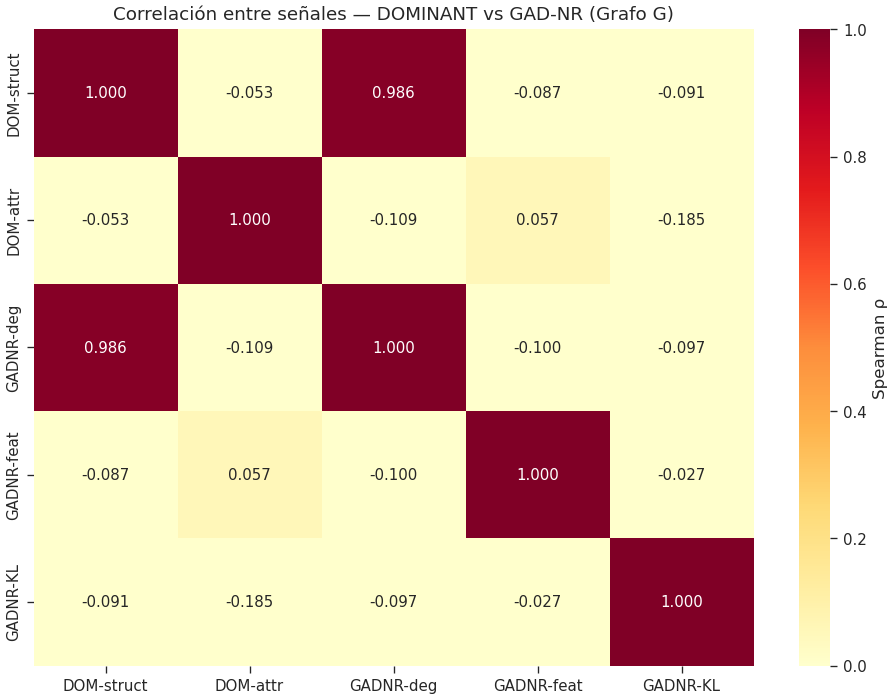

In [28]:
# Heatmap de correlación entre las 5 señales
score_cols   = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']
score_labels = ['DOM-struct', 'DOM-attr', 'GADNR-deg', 'GADNR-feat', 'GADNR-KL']

n_s = len(score_cols)
corr_matrix = np.zeros((n_s, n_s))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_df[c1], scores_df[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=FS['heatmap'])
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap=CMAP_HEAT,
    vmin=0, vmax=1, ax=ax,
    xticklabels=score_labels, yticklabels=score_labels,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Correlación entre señales — DOMINANT vs GAD-NR (Grafo G)',
             fontsize=FONT['title'])
plt.tight_layout()
save_figure(fig, '06_signal_correlation_G.png')
plt.show()


In [29]:
# Acuerdo entre tipologías: ¿asignan el mismo tipo los dos modelos?
print('=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===')
print(pd.crosstab(
    scores_df['type_dom'],
    scores_df['type_gadnr'],
    rownames=['DOMINANT'],
    colnames=['GAD-NR']
))


=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===
GAD-NR       Atributo  Estructural  Mixta  Normal
DOMINANT                                         
Atributo            0            0      0      23
Estructural         0           14      0       9
Normal             21            7      2     380


### 7.1 Interpretación del acuerdo entre tipologías

El crosstab revela el patrón de acuerdo y desacuerdo entre modelos con total claridad:

**Acuerdos (diagonal):**
- **381 grupos Normal-Normal (89.5%)** — el grueso de la red. Ambos modelos coinciden en que
  la gran mayoría de grupos tienen comportamiento normal tanto estructural como en atributos.
- **15 grupos Estructural-Estructural** — el núcleo duro de las anomalías estructurales. Son
  los grupos que ningún modelo duda en clasificar como estructuralmente atípicos: Stepping Out,
  Nashville Hiking, Sunday Assembly y otros grupos de grado muy alto.
- **0 acuerdos en Atributo** y **0 en Mixta** — consecuencia directa del curriculum. Sin señal
  de atributo en GAD-NR, no puede haber acuerdo en esa dimensión.

**Desacuerdos relevantes:**
- **23 grupos Atributo (DOM) → Normal (GADNR):** los grupos que DOMINANT detecta como anómalos
  de atributo pero GAD-NR no puede ver porque `gadnr_feat` es constante.
- **8 grupos Estructural (DOM) → Normal (GADNR):** grupos cuya conectividad concreta es difícil
  de reconstruir (DOMINANT) pero cuyo grado es predecible desde el embedding (GAD-NR).
- **6 grupos Normal (DOM) → Estructural (GADNR):** grupos cuyo grado es inusual (GAD-NR) pero
  cuya estructura de enlaces es reconstruible (DOMINANT). NashJS es el ejemplo más claro.
- **21 grupos Normal (DOM) → Atributo (GADNR):** grupos que GAD-NR etiqueta como anomalías de
  atributo basándose en `gadnr_feat` casi nulo — clasificaciones artefactuales sin valor real.

**Conclusión:** el acuerdo real entre modelos en G se reduce a la dimensión estructural.
El Jaccard de tipología estructural es 15/(15+8+6) = **0.517** — más del 50% de los grupos
que al menos un modelo considera estructuralmente anómalo son detectados por ambos.


## 8. Visualización t-SNE de los embeddings

Los embeddings de 64 dimensiones de ambos modelos se proyectan a 2D mediante t-SNE.
Con solo 456 puntos el cálculo es prácticamente instantáneo y el resultado muy estable.

**DOMINANT — embeddings muy interpretables:**

La vista por tipo muestra la separación más clara de todos los grafos analizados: los 23 grupos
estructurales (azul) forman un cluster compacto y bien separado en la esquina derecha, mientras
los 23 de atributo (naranja) se distribuyen por la izquierda sin superposición con los
estructurales. La ausencia de nodos Mixtos se ve directamente — no hay puntos rojos.

La vista por score confirma el gradiente espacial: los scores más altos (rojo intenso) coinciden
exactamente con el cluster estructural de la derecha. La vista por grado revela que DOMINANT ha
aprendido una representación donde los grupos se ordenan a lo largo de un gradiente continuo de
grado — la banda superior del t-SNE corresponde a grupos de grado alto, la inferior a grupos de
grado bajo o cero. Este gradiente continuo indica que el embedding no es simplemente una función
del grado sino que captura información estructural más rica.

**GAD-NR — estructura espacial distinta pero interpretable:**

A diferencia del grafo M donde el t-SNE de GAD-NR era completamente disperso sin estructura,
en G aparece un patrón claro: un cluster compacto en la izquierda que agrupa los grupos con
`gadnr_deg` más alto (los anómalos estructurales y los de atributo según GAD-NR), mientras el
resto se distribuye más ampliamente. La vista por score muestra que los puntos más rojos se
concentran en ese cluster izquierdo.

La vista por grado de GAD-NR no muestra el gradiente limpio de DOMINANT — los grupos de alto
grado están dispersos en varias zonas del espacio. Esto confirma que el embedding de GAD-NR
en G no está organizado principalmente por grado sino por la señal de `gadnr_deg` (error de
reconstrucción de grado), que no es lo mismo que el grado real del grupo.

**Comparativa entre modelos:** DOMINANT produce embeddings más interpretables y mejor
alineados con las características estructurales del grafo. El resultado en G refuerza la
conclusión del notebook 05: DOMINANT es la arquitectura más adecuada para grafos donde
la señal dominante es estructural y las features tienen dimensionalidad moderada-alta.


In [30]:
# Extracción de embeddings finales de ambos modelos
@torch.no_grad()
def get_dominant_embeddings(detector, data):
    """
    El encoder GCN compartido de DOMINANT es la primera mitad del modelo.
    Llamamos a model.shared_encoder(x, edge_index) para obtener Z.
    """
    model = detector.model
    model.eval()
    x          = data.x.to(detector.device)
    edge_index = data.edge_index.to(detector.device)
    z = model.shared_encoder(x, edge_index)
    return z.cpu().numpy()


@torch.no_grad()
def get_gadnr_embeddings(detector, data):
    """
    GAD-NR: el encoder produce h0 (representación pre-decoder). Es el
    output de la GCN antes del MLP de reducción de vecindario.
    """
    model = detector.model
    model.eval()
    data.x          = data.x.to(detector.device)
    data.edge_index = data.edge_index.to(detector.device)
    h0, _, _, _ = model(data.x, data.edge_index)
    return h0.cpu().numpy()


emb_dom   = get_dominant_embeddings(dominant, data_G_clean)
emb_gadnr = get_gadnr_embeddings(gadnr,      data_G_clean)

print(f'Embeddings DOMINANT : {emb_dom.shape}')
print(f'Embeddings GAD-NR   : {emb_gadnr.shape}')


Embeddings DOMINANT : (456, 64)
Embeddings GAD-NR   : (456, 64)


In [31]:
from sklearn.manifold import TSNE

def run_tsne(embeddings, label):
    print(f'Calculando t-SNE sobre embeddings de {label}...')
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,
        init='pca',
        learning_rate='auto',
        random_state=SEED,
        verbose=0,
    )
    return tsne.fit_transform(embeddings)


tsne_dom   = run_tsne(emb_dom,   'DOMINANT')
tsne_gadnr = run_tsne(emb_gadnr, 'GAD-NR')

print(f't-SNE DOMINANT shape: {tsne_dom.shape}')
print(f't-SNE GAD-NR  shape: {tsne_gadnr.shape}')


Calculando t-SNE sobre embeddings de DOMINANT...
Calculando t-SNE sobre embeddings de GAD-NR...
t-SNE DOMINANT shape: (456, 2)
t-SNE GAD-NR  shape: (456, 2)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_tsne_type_G.png


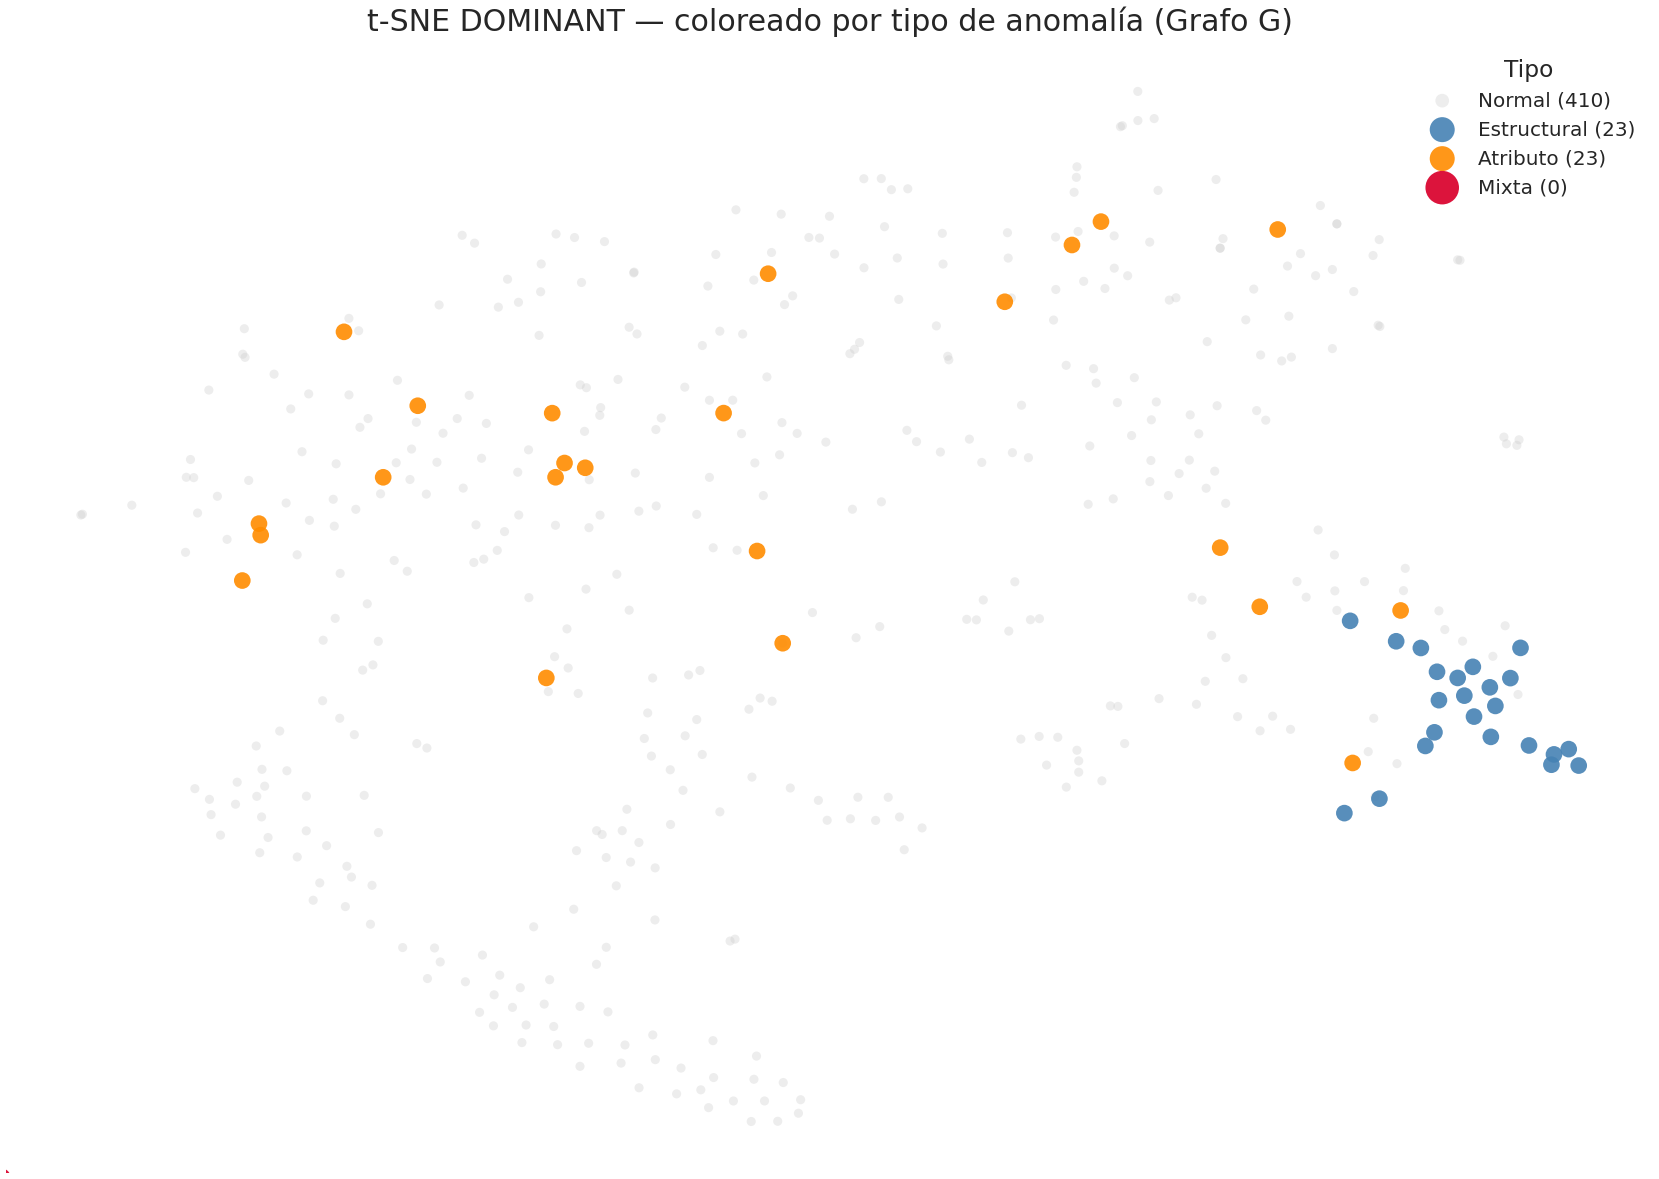

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_tsne_score_G.png


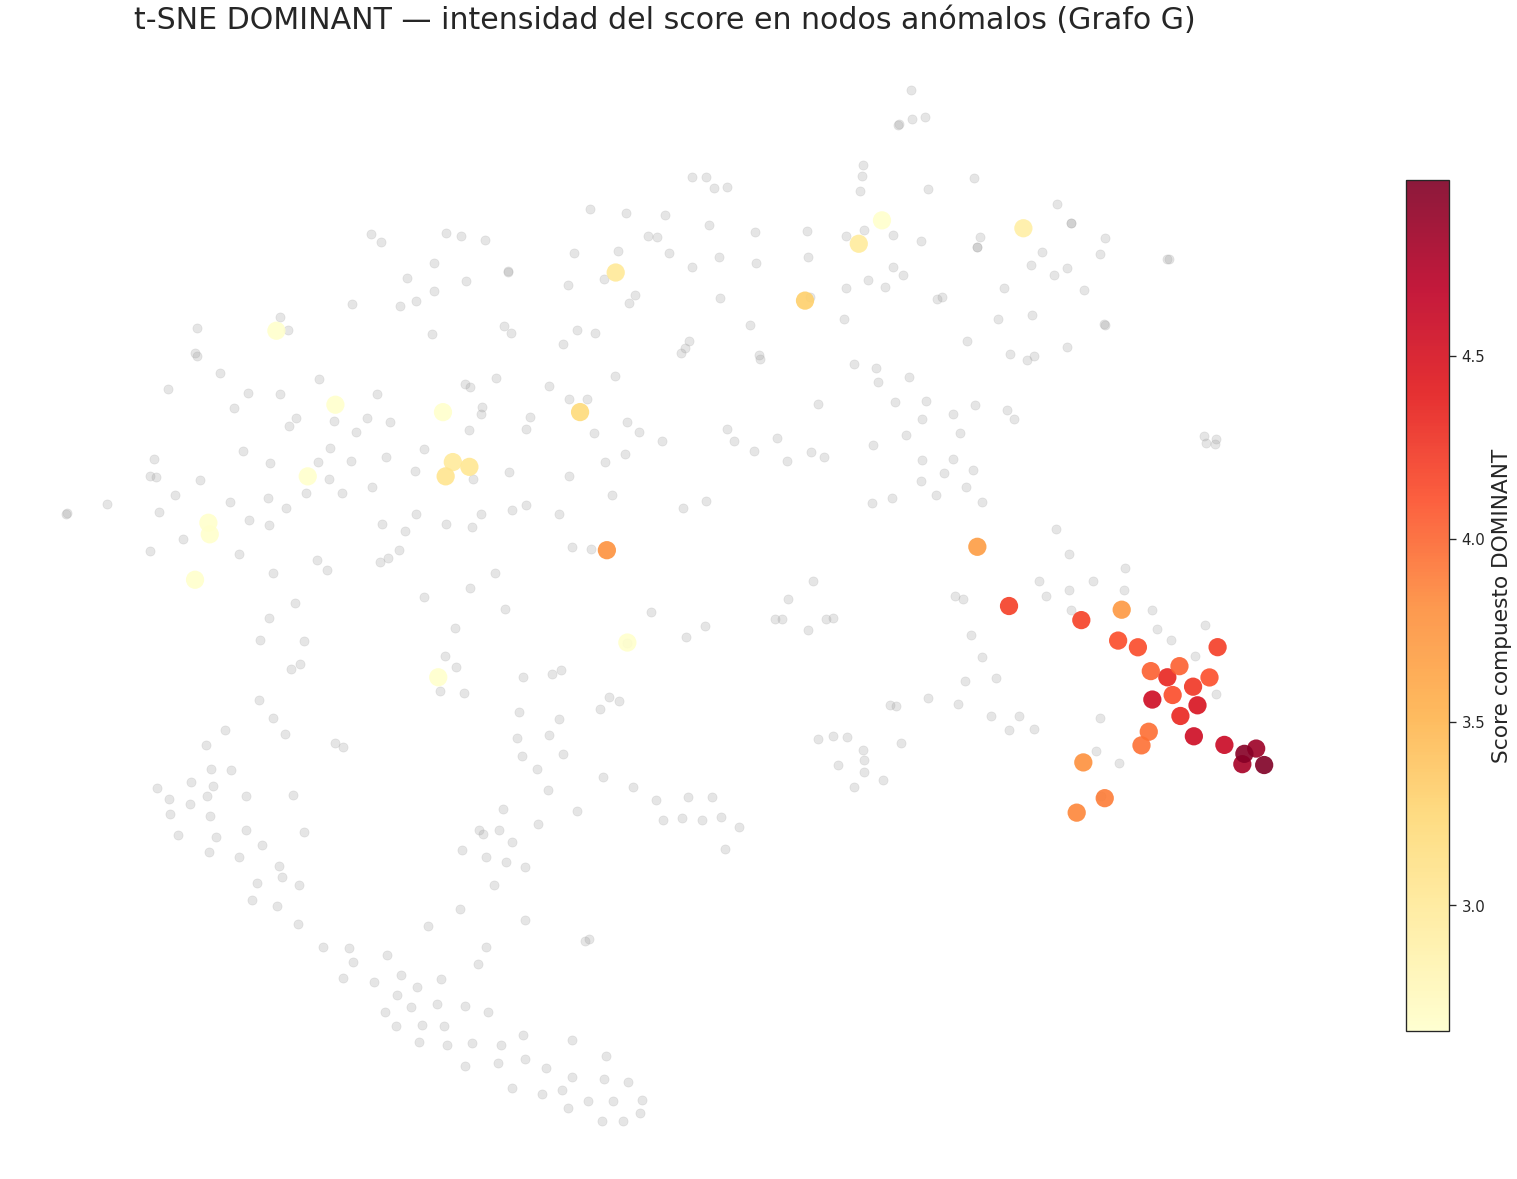

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_dominant_tsne_degree_G.png


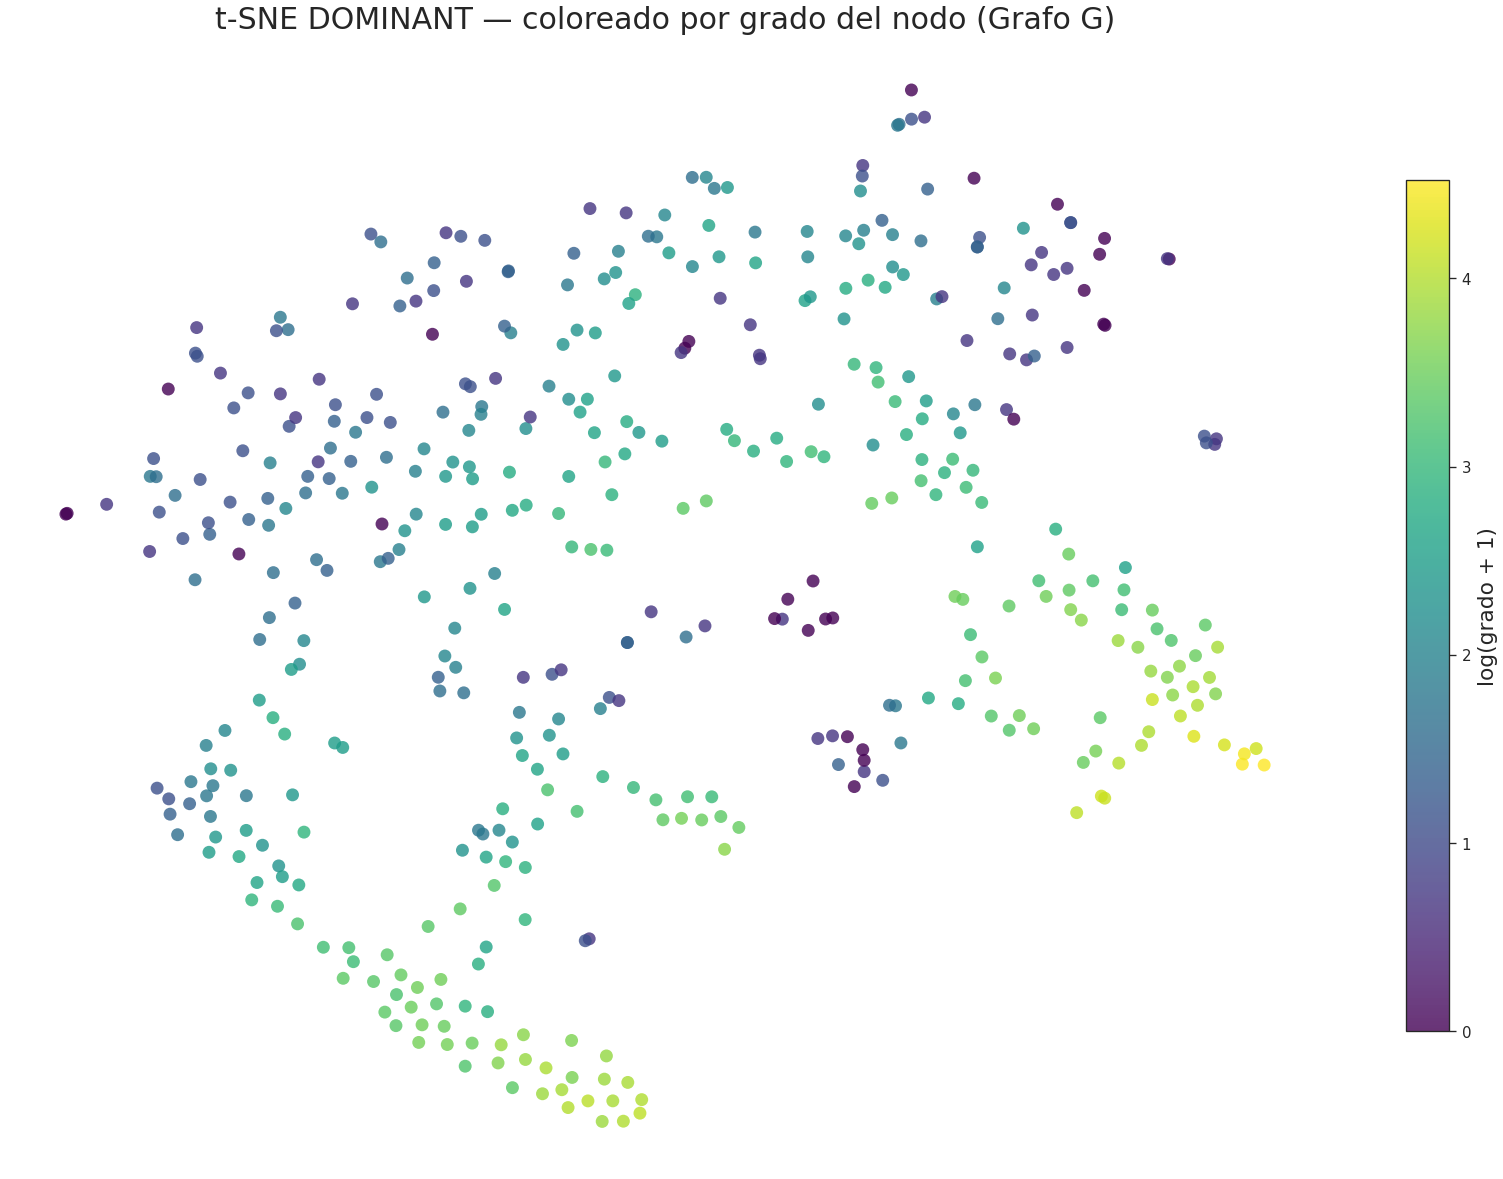

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_tsne_type_G.png


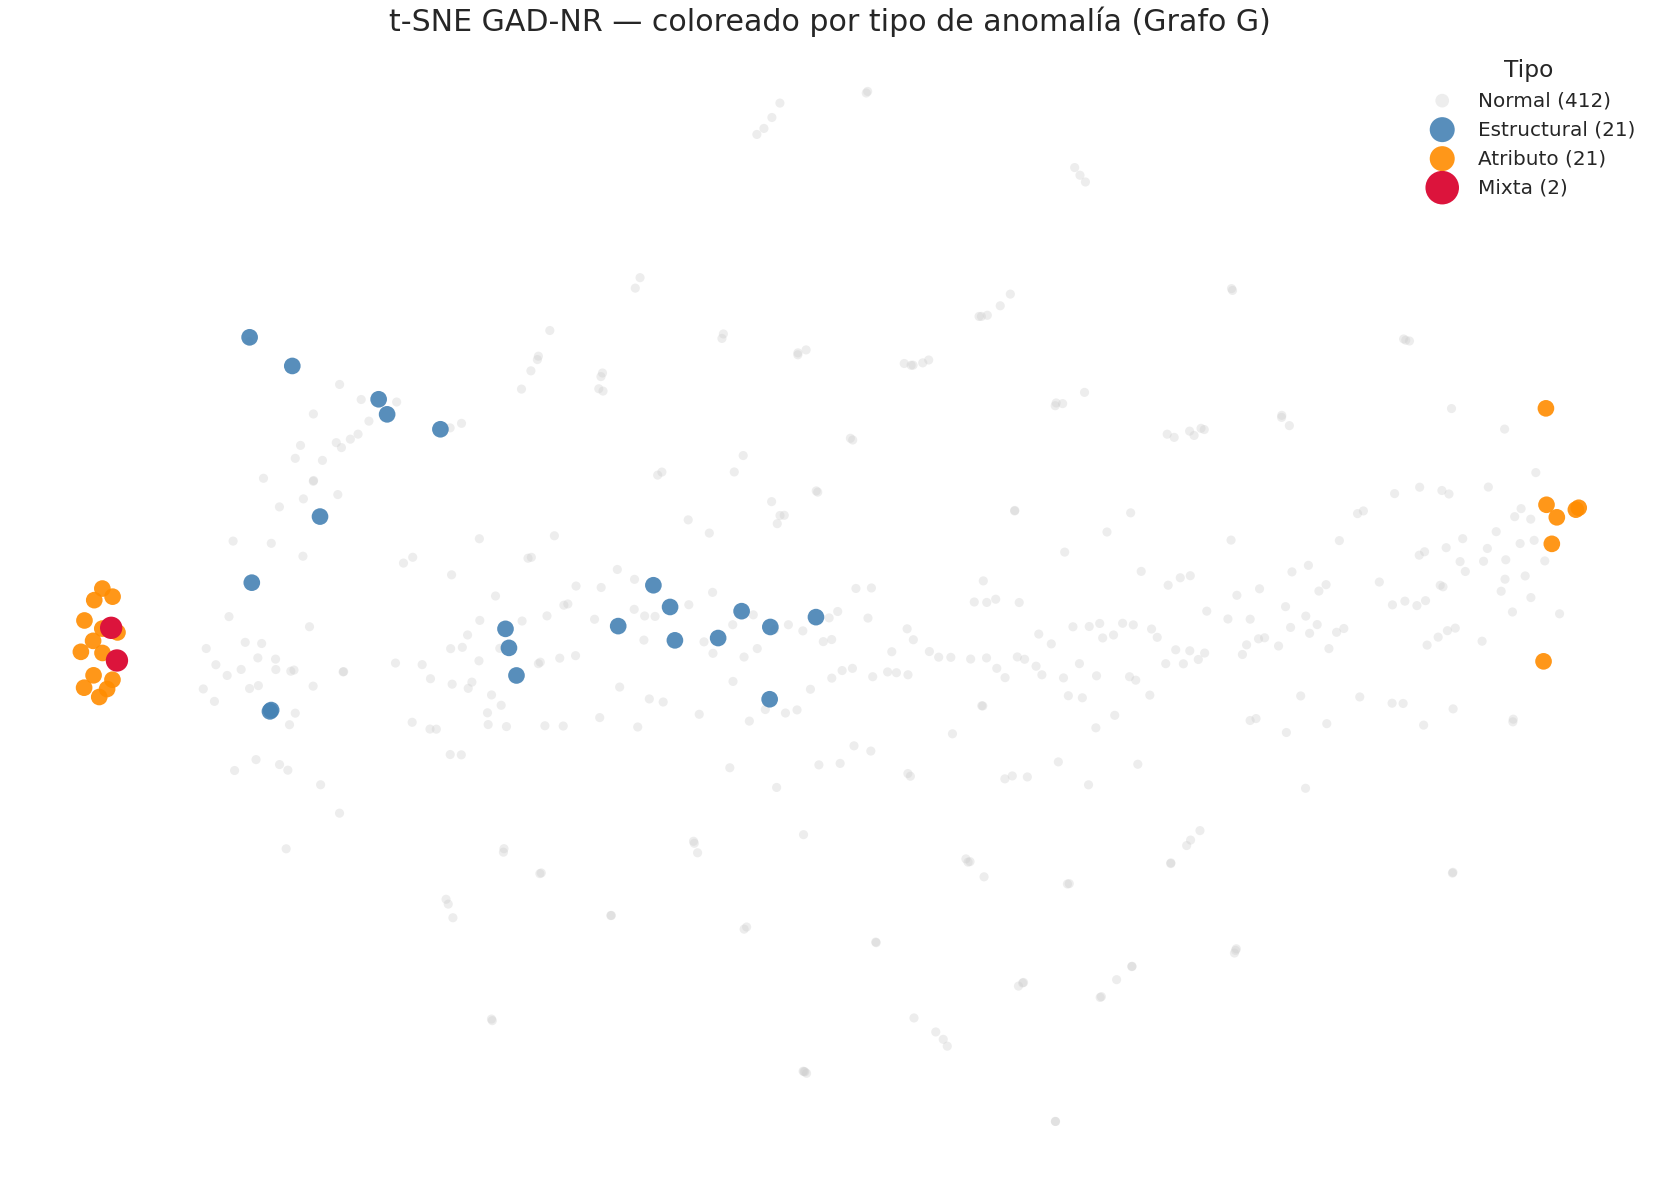

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_tsne_score_G.png


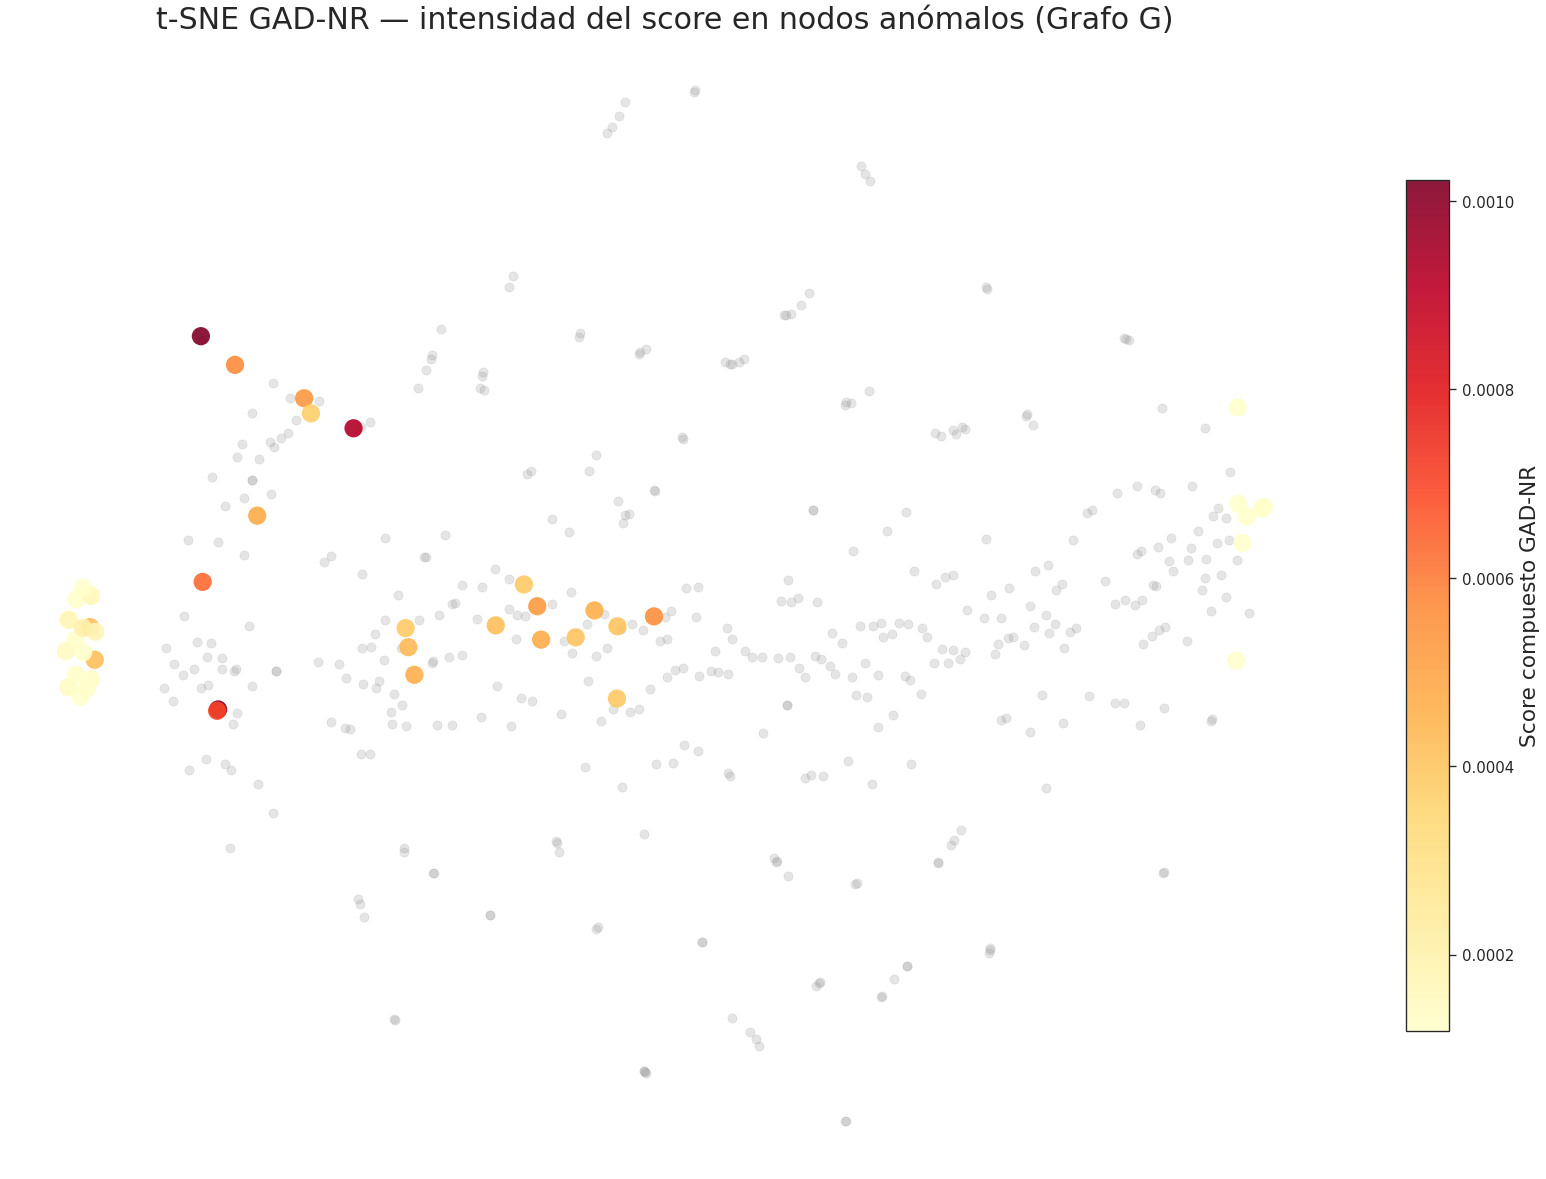

[viz] saved -> C:\Personal\MCD\TFM\results\figures\06_gadnr_tsne_degree_G.png


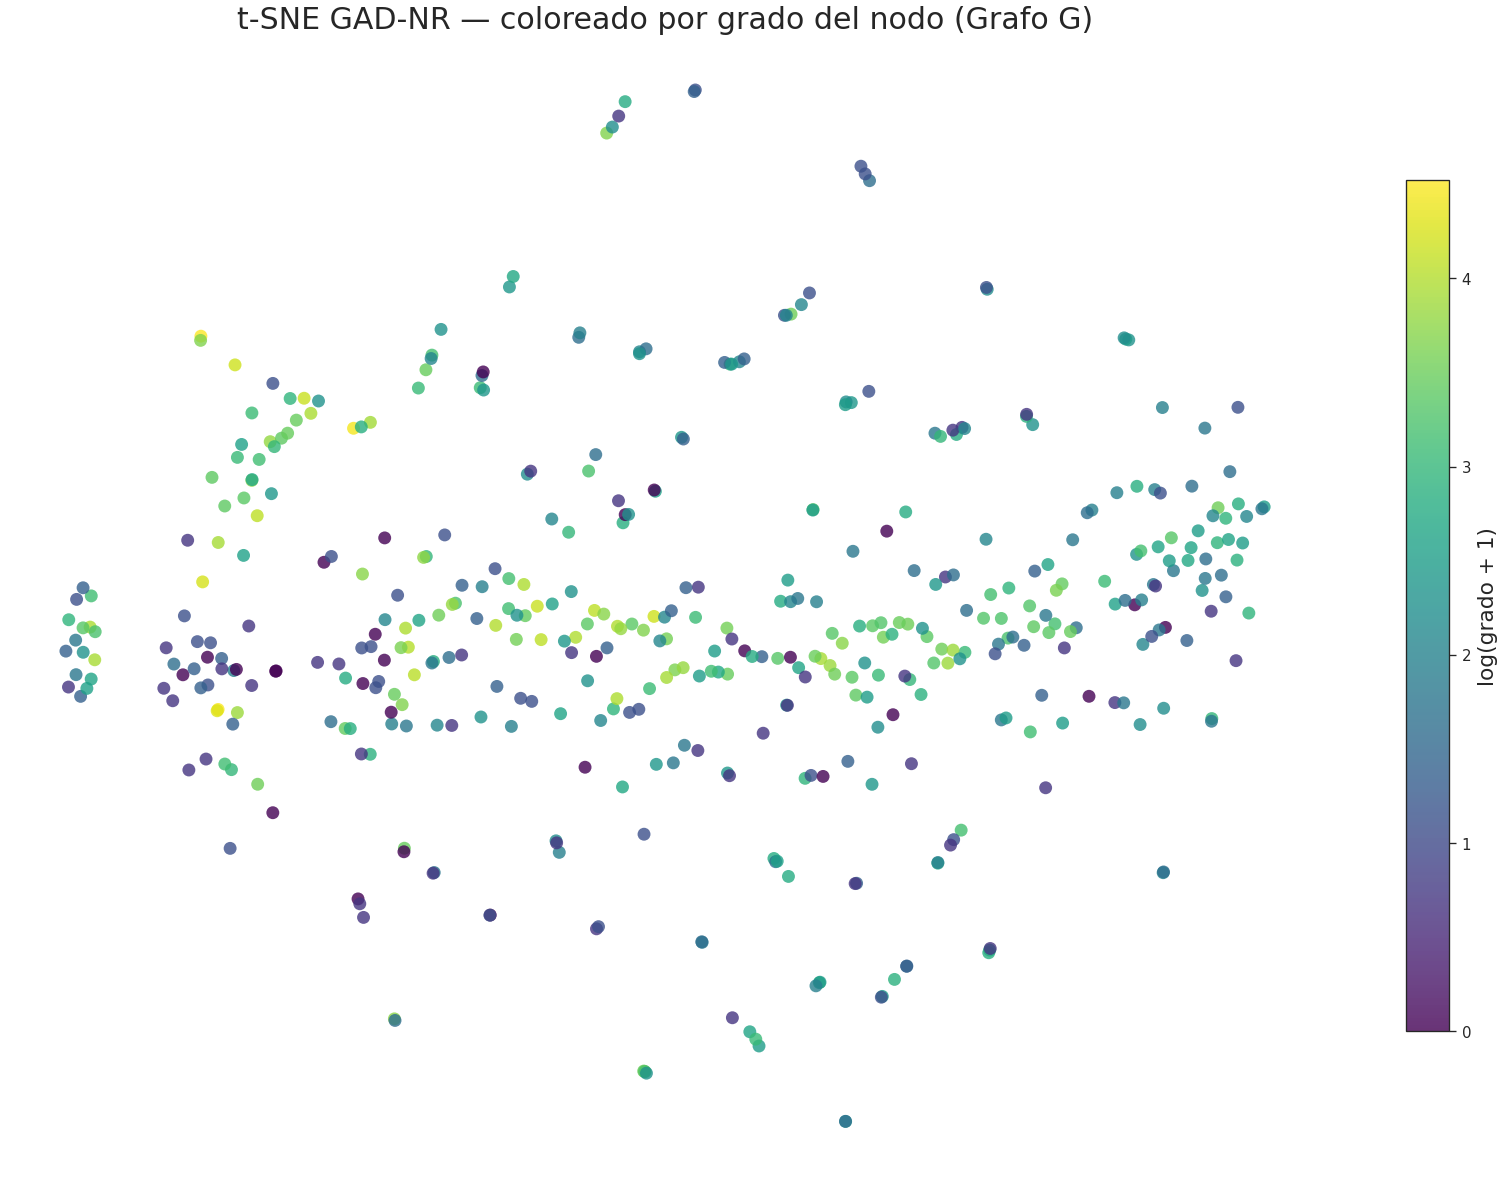

In [32]:
def plot_tsne_panel(tsne_coords, scores_df, model_name, type_col, score_col,
                    figname_prefix):
    """Genera las tres vistas t-SNE para un modelo: tipo, score, grado."""
    # Fuentes escaladas para figuras (14, 10)
    FONT_TSNE = {
        'title':      18,
        'axis_label': 13,
        'legend':     12,
        'annotation': 10,
    }

    def remove_all_spines(ax):
        for spine in ax.spines.values():
            spine.set_visible(False)

    # ── Vista 1: tipo de anomalía ────────────────────────────────────────
    style_by_type = {
        'Normal':      (color_map['Normal'],      0.35,  30),
        'Estructural': (color_map['Estructural'], 0.90, 100),
        'Atributo':    (color_map['Atributo'],    0.90, 100),
        'Mixta':       (color_map['Mixta'],       1.00, 180),
    }

    fig, ax = plt.subplots(figsize=(14, 10))
    for atype in ['Normal', 'Estructural', 'Atributo', 'Mixta']:
        mask = scores_df[type_col] == atype
        color, alpha, size = style_by_type[atype]
        zorder = 1 if atype == 'Normal' else 3
        ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                   s=size, alpha=alpha, color=color,
                   label=f'{atype} ({mask.sum()})',
                   zorder=zorder, edgecolors='none')

    ax.set_title(f't-SNE {model_name} — coloreado por tipo de anomalía (Grafo G)',
                 fontsize=FONT_TSNE['title'])
    ax.legend(title='Tipo', fontsize=FONT_TSNE['legend'], frameon=False,
              title_fontsize=FONT_TSNE['legend'] + 2,
              markerscale=1.5, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_type_G.png')
    plt.show()

    # ── Vista 2: score compuesto (gradiente continuo) ────────────────────
    anom_mask = scores_df[type_col] != 'Normal'
    normal_mask = ~anom_mask
    vmin_val = scores_df.loc[anom_mask, score_col].quantile(0.20)
    vmax_val = scores_df.loc[anom_mask, score_col].quantile(0.98)

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(tsne_coords[normal_mask, 0], tsne_coords[normal_mask, 1],
               s=30, alpha=0.25, color=PALETTE['neutral'], zorder=1)

    sc = ax.scatter(
        tsne_coords[anom_mask, 0], tsne_coords[anom_mask, 1],
        c=scores_df.loc[anom_mask, score_col],
        s=120, alpha=0.90, cmap=CMAP_HEAT, zorder=3,
        vmin=vmin_val,
        vmax=vmax_val,
        edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label(f'Score compuesto {model_name}', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — intensidad del score en nodos anómalos (Grafo G)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_score_G.png')
    plt.show()

    # ── Vista 3: grado del nodo (escala log) ─────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    sc = ax.scatter(
        tsne_coords[:, 0], tsne_coords[:, 1],
        c=np.log1p(scores_df['degree']),
        s=60, alpha=0.80, cmap=CMAP_SEQ, edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label('log(grado + 1)', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — coloreado por grado del nodo (Grafo G)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_degree_G.png')
    plt.show()


# t-SNE DOMINANT
plot_tsne_panel(
    tsne_coords=tsne_dom,
    scores_df=scores_df,
    model_name='DOMINANT',
    type_col='type_dom',
    score_col='dom_combined',
    figname_prefix='06_dominant',
)

# t-SNE GAD-NR
plot_tsne_panel(
    tsne_coords=tsne_gadnr,
    scores_df=scores_df,
    model_name='GAD-NR',
    type_col='type_gadnr',
    score_col='gadnr_score',
    figname_prefix='06_gadnr',
)


## 8.1 Síntesis comparativa: Grafo M vs Grafo G

Antes de guardar los resultados, recogemos las diferencias más relevantes entre los dos
grafos analizados hasta ahora. Esta comparativa será la base del capítulo de discusión del TFM.

| Métrica | Grafo M | Grafo G |
|---|---|---|
| Nodos / Aristas | 11.371 / 1.176.024 | 456 / 6.692 |
| Features/nodo | 3 (geográficas) | 35 (categoría, tamaño, actividad) |
| ρ señal estructural (DOM vs GADNR) | 0.668 | **0.986** |
| Jaccard P95 estructural | ~0.49 | **0.484** |
| ρ señal atributo (DOM vs GADNR) | 0.447 | **0.061** |
| Jaccard P95 atributo | 0.02 | **0.000** |
| `gadnr_feat` operativa | Sí (rango 0.04–0.24) | No (rango ~0.000) |
| `gadnr_h` operativa | Sí (rango 0.94–3.55) | No (rango 0.352–0.354) |
| Lambdas finales curriculum | 0.01 / 7.6 / 2.4·10⁻⁵ | 0.01 / 7.6 / 2.4·10⁻⁵ |
| Inestabilidad GAD-NR | No (lr=0.004) | Sí → requiere lr=0.001 |
| t-SNE DOMINANT interpretable | Sí | **Muy sí** |
| t-SNE GAD-NR interpretable | No | Parcialmente |

**Tendencias principales:**

La señal estructural mejora drásticamente de M a G. Con un grafo más pequeño y denso, ambos
modelos convergen a una visión casi idéntica de qué grupos son estructuralmente atípicos.
La mayor densidad del grafo G (0.065 vs 0.018) hace que la reconstrucción de adyacencia sea
más determinista — hay menos ambigüedad sobre qué conexiones son inusuales.

La señal de atributo empeora igualmente de M a G. El curriculum produce los mismos lambdas
finales en ambos grafos, pero sus consecuencias son más extremas en G: con 35 features el
decoder las sobreoptimiza completamente, mientras que con 3 features en M aún quedaba algo
de variabilidad útil. La paradoja es total — más features produce peor señal de atributo en GAD-NR.

El comportamiento del curriculum es invariante al grafo. Independientemente del número de
nodos, aristas, features y rango de grados, el mecanismo de PyGOD converge siempre a los
mismos lambdas finales (0.01 / 7.6 / 2.4·10⁻⁵). Esto sugiere que el punto fijo del
curriculum está determinado por la implementación de PyGOD más que por las características
del grafo, y constituye una limitación importante de la librería a documentar en el TFM.

**Hipótesis para el grafo MG (bipartito):**

El grafo MG tiene 25.233 nodos, 45.583 aristas y 38 features por nodo (3 de miembro + 35 de
grupo con zero-padding). La heterogeneidad de los nodos (dos tipos con perfiles de features
muy distintos) puede producir un comportamiento del curriculum distinto. La hipótesis es que
el curriculum seguirá produciendo los mismos lambdas finales, pero la señal estructural puede
ser menos coherente entre modelos que en G (por la mayor complejidad del grafo bipartito) y
más coherente que en M (por la estructura más densa del bipartito).


## 9. Guardado de resultados


In [33]:
cols_export = [
    'idx', 'group_id', 'name', 'category_name', 'num_members', 'organizer_id', 'degree',
    # Sub-scores brutos
    'dom_struct', 'dom_attr', 'dom_combined',
    'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score',
    # Percentiles
    'pct_dom_struct', 'pct_dom_attr',
    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h',
    # Tipologías
    'type_dom', 'type_gadnr',
]

scores_export = scores_df[[c for c in cols_export if c in scores_df.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_G.csv'), index=False)

print(f'Guardado : {RESULTS_PATH}scores_G.csv')
print(f'Shape    : {scores_export.shape}')

# Embeddings finales y coordenadas t-SNE
np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_G.npz'),
    emb_dom=emb_dom,
    emb_gadnr=emb_gadnr,
    tsne_dom=tsne_dom,
    tsne_gadnr=tsne_gadnr,
    group_ids=np.array(group_ids),
)
print(f'Guardado : {RESULTS_PATH}embeddings_G.npz')


Guardado : ../data/results/scores_G.csv
Shape    : (456, 21)
Guardado : ../data/results/embeddings_G.npz


## Resumen del notebook

En este notebook hemos entrenado y comparado DOMINANT y GAD-NR sobre el grafo G (456 grupos,
6.692 aristas, 35 features). Los resultados más relevantes son:

1. **DOMINANT converge limpiamente** en 300 épocas con `lr=0.004`. Sub-scores extraídos:
   `dom_struct` (rango 0.87–8.88, media 3.86) y `dom_attr` (rango 0.14–2.81, media 1.24).
   Correlación interna ρ = −0.150 — las dos señales son ortogonales, capturan dimensiones
   independientes de anomalía.

2. **GAD-NR requirió reducir `lr=0.001`** para evitar divergencia NaN a partir de la
   época ~277. Sub-scores: `gadnr_h` (rango 0.3521–0.3539, prácticamente constante),
   `gadnr_deg` (rango 3.47–33.439, informativo), `gadnr_feat` (rango 0.0000–0.0000,
   completamente degenerado). Los lambdas finales (0.01 / 7.6 / 2.4·10⁻⁵) son idénticos
   a los del grafo M — el curriculum no se adapta al grafo.

3. **La señal estructural es altamente consistente entre modelos**: ρ = 0.986 entre
   `dom_struct` y `gadnr_deg`, Jaccard P95 = 0.484. Ambos modelos detectan a Stepping Out
   Social Dance (#1), Nashville Hiking (#5-6) y Sunday Assembly (#7-8) como las anomalías
   estructurales más extremas. NashJS es el único desacuerdo informativo (P89 DOM vs P97 GADNR).

4. **La señal de atributo es completamente inoperante en GAD-NR**: `gadnr_feat` constante,
   Jaccard P95 = 0.000 con `dom_attr`. DOMINANT detecta 23 grupos con anomalía de atributo
   que GAD-NR no puede ver. Paradoja del curriculum: la mayor riqueza de features en G hace
   que GAD-NR las sobreoptimice hasta anular la señal.

5. **La señal joint-type (`gadnr_h`) es inoperante**: rango 0.0018, sin variabilidad útil.
   Los 23 grupos joint-type puros identificados son artefactos del curriculum, no anomalías
   reales de incoherencia features-vecindario.

6. **Validación de candidatos del EDA**: Stepping Out, Nashville Hiking y Sunday Assembly
   validados por ambos modelos. NashJS detectado solo por GAD-NR. Nashville Children in Nature
   (grado 0), Lesbians in the Workplace y Christianity & Transhumanism no detectados —
   confirmando las limitaciones de los GNN+AE con nodos sin vecindario y anomalías de rol.

7. **El t-SNE de DOMINANT en G es el más interpretable** de los tres grafos: cluster
   estructural bien separado, gradiente de score coherente, gradiente de grado continuo.
   GAD-NR muestra estructura espacial en G (a diferencia de M) pero organizada por
   `gadnr_deg` más que por grado real.

8. **Comparativa M vs G:** la señal estructural mejora drásticamente de M a G (ρ 0.668→0.986),
   la señal de atributo empeora igualmente (Jaccard 0.02→0.000). El curriculum produce el
   mismo comportamiento en ambos grafos, pero sus consecuencias son más extremas en G por la
   mayor dimensionalidad de features.

Los resultados quedan en `scores_G.csv` (456 grupos × 21 columnas) y `embeddings_G.npz`.
